# Date Fields EDA — DeathDate, Echo_Date, Dialysis_Start_Date

**Goal:** Rich summary statistics + exclusion flags to inform modeling decisions.

**What you get:**
- Robust date parsing (handles mixed DD/MM/YYYY and ISO formats)
- Missingness, duplicates, impossible/illogical sequences
- Echo-to-Dialysis gap stats (days), distributions, window counts (≤3/6/12 months)
- Follow-up time stats (dialysis → death or dialysis → censor)
- Candidate exclusion lists with reasons + a tunable `keep_mask`

**Usage:**
1. Upload your xlsx or mount Google Drive
2. Set `FILE_PATH` and column names in the CONFIG cell
3. Run all cells

## 0. חיבור Google Drive

מבנה התיקיות הצפוי:
```
My Drive/
└── dialysis/
    └── data/
        └── echo_project_update_cleaned_2202.xlsx   ← הקובץ שלך
```
לאחר הרצת התא יפתח חלון הרשאה — אשרי גישה לדרייב.

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ── נתיב לתיקיית הנתונים ────────────────────────────────────────────────────
DRIVE_BASE = "/content/drive/MyDrive/dialysis/data"

# בדיקה שהתיקייה קיימת
if os.path.isdir(DRIVE_BASE):
    files = os.listdir(DRIVE_BASE)
    print(f"✅ התיקייה נמצאה: {DRIVE_BASE}")
    print(f"   קבצים בתיקייה: {files}")
else:
    print(f"⚠️  התיקייה לא נמצאה: {DRIVE_BASE}")
    print("   בדקי שהמבנה הוא: My Drive > dialysis > data")

## 0b. Install / upgrade pandas (optional)
Uncomment if you need a specific version.

In [3]:
# !pip install -q --upgrade pandas

## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print(f"pandas version: {pd.__version__}")
print(f"numpy version:  {np.__version__}")

pandas version: 2.2.2
numpy version:  2.0.2


## 2. Configuration
**Edit this cell before running.**

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE CONFIGURATION — edit this cell to change anchor mode, windows, etc.
# ═══════════════════════════════════════════════════════════════════════════════
CONFIG = {
    # ── Anchor mode ──
    "ANCHOR_MODE": "echo",                # "echo" | "dialysis"

    # ── File paths ──
    "FILE_PATH": "/content/drive/MyDrive/dialysis/data/echo_project_update_cleaned_2202.xlsx",
    "SHEET_NAME": 0,
    "DRIVE_BASE": "/content/drive/MyDrive/dialysis/data",
    "OUTPUT_DIR": "/content/drive/MyDrive/dialysis/outputs",

    # ── Column names ──
    "COL_PATIENT": "patient number",
    "COL_DEATH":   "DeathDate",
    "COL_ECHO":    "Echo_Date",
    "COL_DIAL":    "Dialysis_Start_Date",
    "COL_LAST_FU": None,          # e.g. "LastFollowUpDate"

    # ── Cohort filters ──
    "ECHO_BEFORE_DIALYSIS_ONLY": True,
    "ECHO_TO_DIALYSIS_WINDOW_DAYS": 180,  # primary; use 365 for sensitivity
    "EXCLUDE_EARLY_DEATH_DAYS": None,     # set to 30 for sensitivity

    # ── Target ──
    "HORIZON_DAYS": 365,
    "FOLLOWUP_MODE": "proxy_dataset_end",  # "strict_drop_unknown" | "proxy_dataset_end"
    "DATASET_END_DATE": None,              # computed at runtime from max(all dates)

    # ── Modeling ──
    "BOOTSTRAP_N": 200,
    "N_SPLITS": 5,
    "RANDOM_STATE": 42,
}

# ── Backward-compatible aliases (so EDA cells 9-36 work unchanged) ──
FILE_PATH        = CONFIG["FILE_PATH"]
SHEET_NAME       = CONFIG["SHEET_NAME"]
DRIVE_BASE       = CONFIG["DRIVE_BASE"]
COL_PATIENT      = CONFIG["COL_PATIENT"]
COL_DEATH        = CONFIG["COL_DEATH"]
COL_ECHO         = CONFIG["COL_ECHO"]
COL_DIAL         = CONFIG["COL_DIAL"]
COL_LAST_FU      = CONFIG["COL_LAST_FU"]
EXTRA_DATE_COLS  = []
WINDOWS_MONTHS   = [3, 6, 12]
KEEP_WINDOW_MONTHS = int(CONFIG["ECHO_TO_DIALYSIS_WINDOW_DAYS"] / 30.44)

print(f"Anchor mode:  {CONFIG['ANCHOR_MODE']}")
print(f"Echo window:  {CONFIG['ECHO_TO_DIALYSIS_WINDOW_DAYS']}d")
print(f"Follow-up:    {CONFIG['FOLLOWUP_MODE']}")
print(f"Early death:  {CONFIG['EXCLUDE_EARLY_DEATH_DAYS']}")

## 3. Load data

In [6]:
# openpyxl נדרש לקריאת xlsx — בדרך כלל כבר מותקן ב-Colab
# !pip install -q openpyxl

# הצג את כל ה-sheets בקובץ לפני הבחירה
xl = pd.ExcelFile(FILE_PATH, engine='openpyxl')
print(f"Sheets בקובץ: {xl.sheet_names}")

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine='openpyxl')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Sheets בקובץ: ['Sheet1']
Shape: (645, 66)
Columns: ['patient number', 'HD/PD', 'm/f', 'AgeAtFirstHFDate', 'DeathDate', 'Dialysis_Start_Date', 'Echo_Date', 'LeftVentricleCavitySize', 'LeftVentricleWallThickness', 'LeftVentricleSystolicFunction', 'LeftVentricleSummary', 'LV_EF', 'RVSize', 'RVSystolicFunction', 'LACavitySize', 'AorticValveStructure', 'AorticValveRegurgitation', 'AorticValveSummary', 'MitralValveStructure', 'MitralRegurgitation', 'MitralValveSummary', 'TricuspidValveStructure', 'TricuspidRegurgitation', 'ECHO_SPAP', 'LeftVentricleEndDiastolicDiameter', 'LeftVentricleEndSystolicDiameter', 'LeftVentricleInterventricularSeptumThickness', 'LeftVentriclePosteriorWallThickness', 'LeftVentricleEstimatedMass', 'LeftVentricleEstimatedMassIndex', 'LeftVentricleScoreIndex', 'EstimatedSysPAPressure', 'MitralInflowPeakEWave', 'TissueDopplerSVelocitySeptal', 'TissueDopplerEVelositySeptal', 'TissueDopplerEERatioSeptal', 'TissueDopplerSVelocityLateral', 'TissueDopplerEVelosityLateral', 'T

,patient number,HD/PD,m/f,AgeAtFirstHFDate,DeathDate,Dialysis_Start_Date,Echo_Date,LeftVentricleCavitySize,LeftVentricleWallThickness,LeftVentricleSystolicFunction,...,k-numeric result,albumin-numeric result,hb-numeric result,urea-numeric result,creatinine-numeric result,ca-numeric result,p-numeric result,ua-numeric result,crp-numeric result,hba1c-numeric result
0,1,HD,m,74.0,NaT,2021-12-28,2021-12-13 09:31:53,Normal,Mildly increased,Normal,...,3.7,3.2,9.21,193.0,7.60,9.6,6.2,6.6,21.58,4.9
1,2,HD,m,59.0,2020-02-13,2009-04-13,2009-03-30 12:28:29,Normal,NaN,Normal,...,4.7,3.9,9.17,206.0,5.20,8.9,5.1,8.6,NaN,NaN
2,3,HD,f,67.0,2017-09-01,2016-07-19,2016-04-12 13:33:31,NaN,NaN,NaN,...,4.2,2.8,9.49,365.0,6.96,6.1,8.2,9.7,3.08,9.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 66 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   patient number                                645 non-null    int64         
 1   HD/PD                                         645 non-null    object        
 2   m/f                                           644 non-null    object        
 3   AgeAtFirstHFDate                              645 non-null    float64       
 4   DeathDate                                     506 non-null    datetime64[ns]
 5   Dialysis_Start_Date                           645 non-null    datetime64[ns]
 6   Echo_Date                                     645 non-null    datetime64[ns]
 7   LeftVentricleCavitySize                       616 non-null    object        
 8   LeftVentricleWallThickness                    545 non-null    object  

## 4. Robust date parsing

> **Note:** `infer_datetime_format` was deprecated in pandas ≥ 2.0.  
> The function below uses `format='mixed'` when available (pandas ≥ 2.0) and falls back gracefully for older versions.  
> For Israeli data (DD/MM/YYYY), `dayfirst=True` is tried on any rows that fail the first pass.

In [8]:
def parse_date_series(s: pd.Series) -> pd.Series:
    """
    Robust two-pass date parser.
    Pass 1 – dayfirst=False (ISO / US format).
    Pass 2 – dayfirst=True  (DD/MM/YYYY) on rows that still failed.
    Compatible with pandas < 2.0 and >= 2.0.
    """
    if s is None:
        return s

    pd_major = int(pd.__version__.split(".")[0])

    def _to_dt(series, dayfirst):
        if pd_major >= 2:
            return pd.to_datetime(series, errors="coerce", format="mixed",
                                  dayfirst=dayfirst)
        else:
            return pd.to_datetime(series, errors="coerce",
                                  infer_datetime_format=True, dayfirst=dayfirst)

    d1 = _to_dt(s, dayfirst=False)

    # Second pass on failures
    mask_fail = d1.isna() & s.notna() & (s.astype(str).str.strip() != "")
    if mask_fail.any():
        d2 = _to_dt(s[mask_fail], dayfirst=True)
        d1 = d1.copy()
        d1.loc[mask_fail] = d2

    return d1


date_cols = [COL_DEATH, COL_ECHO, COL_DIAL] + EXTRA_DATE_COLS
for c in date_cols:
    if c in df.columns:
        df[c] = parse_date_series(df[c])
    else:
        print(f"⚠️  Column not found: {c}")

print("Date dtypes after parsing:")
display(df[date_cols].dtypes.to_frame("dtype"))

Date dtypes after parsing:


,dtype
DeathDate,datetime64[ns]
Echo_Date,datetime64[ns]
Dialysis_Start_Date,datetime64[ns]


## 5. Basic overview — missingness & duplicates

In [9]:
print(f"Total rows:        {len(df)}")
if COL_PATIENT in df.columns:
    print(f"Unique patients:   {df[COL_PATIENT].nunique()}")

# Missingness
miss = pd.DataFrame({
    "missing_n": [df[c].isna().sum() for c in [COL_DIAL, COL_ECHO, COL_DEATH]],
    "missing_%": [round(df[c].isna().mean() * 100, 1)
                  for c in [COL_DIAL, COL_ECHO, COL_DEATH]],
}, index=[COL_DIAL, COL_ECHO, COL_DEATH]).sort_values("missing_%", ascending=False)

print("\n=== Missingness (key dates) ===")
display(miss)

# Rows per patient
if COL_PATIENT in df.columns:
    dup_counts = df.groupby(COL_PATIENT).size().value_counts().sort_index()
    print("\n=== Rows per patient (detect duplicates) ===")
    display(dup_counts.to_frame("n_patients"))

Total rows:        645
Unique patients:   645

=== Missingness (key dates) ===


,missing_n,missing_%
DeathDate,139,21.6
Dialysis_Start_Date,0,0.0
Echo_Date,0,0.0



=== Rows per patient (detect duplicates) ===


,n_patients
1,645


## 6. Derived time variables

In [ ]:
# ── Derived time variables (anchor-aware) ──────────────────────────────────────

# Core gaps (always computed regardless of anchor mode)
df["gap_echo_to_dial_days"]   = (df[COL_DIAL]  - df[COL_ECHO]).dt.days
df["time_dial_to_death_days"] = (df[COL_DEATH] - df[COL_DIAL]).dt.days
df["time_echo_to_death_days"] = (df[COL_DEATH] - df[COL_ECHO]).dt.days

# Censor date
if COL_LAST_FU and COL_LAST_FU in df.columns:
    df[COL_LAST_FU] = parse_date_series(df[COL_LAST_FU])
    df["censor_date"] = df[COL_LAST_FU]
    print(f"Using explicit censor column: {COL_LAST_FU}")
else:
    max_date = pd.concat([df[COL_DIAL], df[COL_ECHO], df[COL_DEATH]], axis=0).dropna().max()
    df["censor_date"] = max_date
    CONFIG["DATASET_END_DATE"] = max_date
    print(f"No COL_LAST_FU set. Using dataset max date as proxy censor: {max_date.date()}")

# Anchor-relative columns
if CONFIG["ANCHOR_MODE"] == "echo":
    df["anchor_date"] = df[COL_ECHO]
    df["gap_anchor_to_death_days"] = df["time_echo_to_death_days"]
    print(f"Anchor = Echo_Date")
else:
    df["anchor_date"] = df[COL_DIAL]
    df["gap_anchor_to_death_days"] = df["time_dial_to_death_days"]
    print(f"Anchor = Dialysis_Start_Date")

df["death_event"] = df[COL_DEATH].notna().astype(int)
df["time_anchor_to_censor_days"] = (df["censor_date"] - df["anchor_date"]).dt.days

# Backward-compat: time_to_event_or_censor_days is now anchor-relative
df["time_dial_to_censor_days"] = (df["censor_date"] - df[COL_DIAL]).dt.days
df["time_to_event_or_censor_days"] = np.where(
    df["death_event"].eq(1),
    df["gap_anchor_to_death_days"],
    df["time_anchor_to_censor_days"]
)

print(f"\nDerived columns created ({len(df)} rows)")
display(df[[COL_DIAL, COL_ECHO, COL_DEATH,
            "gap_echo_to_dial_days", "death_event",
            "time_to_event_or_censor_days"]].head(3))

## 7. Summary statistics

In [11]:
def rich_numeric_summary(s: pd.Series) -> pd.DataFrame:
    s = s.dropna()
    if len(s) == 0:
        return pd.DataFrame({"value": []})
    q = s.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    return pd.DataFrame({
        "n": len(s), "mean": s.mean(), "std": s.std(ddof=1),
        "min": s.min(),
        "p01": q[0.01], "p05": q[0.05], "p10": q[0.10], "p25": q[0.25],
        "median": q[0.50],
        "p75": q[0.75], "p90": q[0.90], "p95": q[0.95], "p99": q[0.99],
        "max": s.max(),
    }, index=["value"]).T


def rich_date_summary(s: pd.Series) -> pd.DataFrame:
    """
    NOTE: pd.Series.quantile() on datetime is deprecated in pandas >= 2.0.
    We use np.percentile via astype('int64') as a safe alternative.
    """
    s = s.dropna()
    if len(s) == 0:
        return pd.DataFrame({"value": []})

    def _pct(p):
        return pd.Timestamp(int(np.percentile(s.astype("int64"), p)))

    return pd.DataFrame({
        "n": len(s),
        "min_date": s.min(),
        "p05":      _pct(5),
        "p25":      _pct(25),
        "median":   _pct(50),
        "p75":      _pct(75),
        "p95":      _pct(95),
        "max_date": s.max(),
    }, index=["value"]).T

In [12]:
print("=== Date field summaries ===")
for c in [COL_DIAL, COL_ECHO, COL_DEATH]:
    print(f"\n--- {c} ---")
    display(rich_date_summary(df[c]))

=== Date field summaries ===

--- Dialysis_Start_Date ---


,value
n,645
min_date,2009-04-13 00:00:00
p05,2011-07-13 00:00:00
p25,2014-10-23 00:00:00
median,2018-01-09 00:00:00
p75,2021-05-05 00:00:00
p95,2024-08-03 14:24:00
max_date,2025-06-12 15:12:00



--- Echo_Date ---


,value
n,645
min_date,2009-02-12 15:30:07
p05,2011-03-08 09:39:00.800000
p25,2014-06-26 10:46:06
median,2017-08-27 08:38:05
p75,2021-02-01 10:43:32
p95,2024-02-18 19:32:59.400000
max_date,2025-06-03 12:53:36



--- DeathDate ---


,value
n,506
min_date,2012-02-17 00:00:00
p05,2013-03-18 12:00:00
p25,2016-05-02 15:37:30
median,2019-06-22 04:48:00
p75,2022-05-28 10:18:00
p95,2024-05-14 01:02:15
max_date,2025-08-16 00:00:00


In [13]:
print("=== Derived time summaries (days) ===")
for c in ["gap_echo_to_dial_days", "time_dial_to_death_days",
          "time_to_event_or_censor_days"]:
    print(f"\n--- {c} ---")
    display(rich_numeric_summary(df[c]))

=== Derived time summaries (days) ===

--- gap_echo_to_dial_days ---


,value
n,645.000000
mean,116.310078
std,125.108847
min,-68.000000
p01,-47.120000
p05,-22.800000
p10,-11.000000
p25,4.000000
median,69.000000
p75,226.000000



--- time_dial_to_death_days ---


,value
n,506.000000
mean,721.849802
std,838.047694
min,1.000000
p01,4.000000
p05,14.000000
p10,24.500000
p25,80.500000
median,417.500000
p75,1047.500000



--- time_to_event_or_censor_days ---


,value
n,645.000000
mean,919.327132
std,1058.860079
min,1.000000
p01,4.000000
p05,17.200000
p10,30.000000
p25,125.000000
median,553.000000
p75,1307.000000


## 8. Sanity checks & exclusion flags

In [14]:
df["flag_missing_dialysis_start"]       = df[COL_DIAL].isna()
df["flag_missing_echo_date"]            = df[COL_ECHO].isna()
df["flag_echo_after_dialysis"]          = (
    df["gap_echo_to_dial_days"].notna() & (df["gap_echo_to_dial_days"] < 0)
)
df["flag_echo_more_than_12m_before"]    = (
    df["gap_echo_to_dial_days"].notna() & (df["gap_echo_to_dial_days"] > 365)
)
df["flag_death_before_dialysis"]        = (
    df[COL_DEATH].notna() & df[COL_DIAL].notna() &
    (df["time_dial_to_death_days"] < 0)
)
df["flag_death_before_echo"]            = (
    df[COL_DEATH].notna() & df[COL_ECHO].notna() &
    ((df[COL_DEATH] - df[COL_ECHO]).dt.days < 0)
)
df["flag_followup_negative"]            = (
    df["time_to_event_or_censor_days"].notna() &
    (df["time_to_event_or_censor_days"] < 0)
)

flag_cols = [c for c in df.columns if c.startswith("flag_")]
flag_summary = pd.DataFrame({
    "flag": flag_cols,
    "n":    [df[c].sum() for c in flag_cols],
    "%":    [round(df[c].mean() * 100, 1) for c in flag_cols],
}).sort_values("n", ascending=False)

print("=== Flag summary (potential exclusions / data issues) ===")
display(flag_summary)

=== Flag summary (potential exclusions / data issues) ===


,flag,n,%
2,flag_echo_after_dialysis,117,18.1
5,flag_death_before_echo,1,0.2
0,flag_missing_dialysis_start,0,0.0
1,flag_missing_echo_date,0,0.0
3,flag_echo_more_than_12m_before,0,0.0
4,flag_death_before_dialysis,0,0.0
6,flag_followup_negative,0,0.0


## 9. Echo-to-Dialysis window coverage

In [15]:
def window_counts(gap_days: pd.Series, months: int) -> int:
    return int(((gap_days >= 0) & (gap_days <= months * 30.44)).sum())

window_table = pd.DataFrame([
    {
        "window_months": m,
        "n_in_window":  window_counts(df["gap_echo_to_dial_days"], m),
        "pct_in_window": round(
            window_counts(df["gap_echo_to_dial_days"], m) / len(df) * 100, 1
        ),
    }
    for m in WINDOWS_MONTHS
])

print("=== Echo-to-dialysis window coverage ===")
display(window_table)

# Gap bins
bins   = [-np.inf, 0, 90, 180, 365, np.inf]
labels = ["echo after dialysis (<0)", "0–90d", "91–180d", "181–365d", ">365d"]
df["gap_bin"] = pd.cut(
    df["gap_echo_to_dial_days"], bins=bins, labels=labels, right=True
)

gap_bin_counts = df["gap_bin"].value_counts(dropna=False).to_frame("n")
gap_bin_counts["%"] = (gap_bin_counts["n"] / len(df) * 100).round(1)

print("\n=== Gap bins (Echo → Dialysis) ===")
display(gap_bin_counts)

=== Echo-to-dialysis window coverage ===


,window_months,n_in_window,pct_in_window
0,3,226,35.0
1,6,322,49.9
2,12,528,81.9



=== Gap bins (Echo → Dialysis) ===


,n,%
gap_bin,,
0–90d,211,32.7
181–365d,209,32.4
echo after dialysis (<0),130,20.2
91–180d,95,14.7
>365d,0,0.0


## 10. Keep / drop rule for the echo model

Default conservative rule:
- Dialysis start present
- Echo date present
- Echo **before** dialysis start (gap ≥ 0)
- Echo within `KEEP_WINDOW_MONTHS` months

Adjust `KEEP_WINDOW_MONTHS` in the CONFIG cell as needed.

In [16]:
keep_mask = (
    df[COL_DIAL].notna() &
    df[COL_ECHO].notna() &
    (df["gap_echo_to_dial_days"] >= 0) &
    (df["gap_echo_to_dial_days"] <= KEEP_WINDOW_MONTHS * 30.44)
)
df["keep_for_echo_model"] = keep_mask

print(f"Keep rule: echo before dialysis AND within {KEEP_WINDOW_MONTHS} months")
print(f"  Keep n : {int(keep_mask.sum())}")
print(f"  Drop n : {int((~keep_mask).sum())}")


def drop_reason(row):
    reasons = []
    if pd.isna(row[COL_DIAL]):   reasons.append("Missing Dialysis_Start_Date")
    if pd.isna(row[COL_ECHO]):   reasons.append("Missing Echo_Date")
    gap = row["gap_echo_to_dial_days"]
    if pd.notna(gap) and gap < 0:
        reasons.append("Echo after dialysis start (gap < 0)")
    if pd.notna(gap) and gap > KEEP_WINDOW_MONTHS * 30.44:
        reasons.append(f"Echo too old (> {KEEP_WINDOW_MONTHS} months)")
    if row.get("flag_death_before_dialysis", False):
        reasons.append("DeathDate before Dialysis_Start_Date (likely data error)")
    return "; ".join(reasons) if reasons else "unknown"


drop_df = df.loc[
    ~df["keep_for_echo_model"],
    [COL_PATIENT, COL_DIAL, COL_ECHO, COL_DEATH, "gap_echo_to_dial_days"]
].copy()
drop_df["drop_reason"] = df.loc[~df["keep_for_echo_model"]].apply(drop_reason, axis=1)

print("\n=== Sample of dropped rows with reasons ===")
display(drop_df.head(20))

Keep rule: echo before dialysis AND within 12 months
  Keep n : 528
  Drop n : 117

=== Sample of dropped rows with reasons ===


,patient number,Dialysis_Start_Date,Echo_Date,DeathDate,gap_echo_to_dial_days,drop_reason
3,4,2016-10-16,2016-10-20 14:21:41,2021-11-25,-5,Echo after dialysis start (gap < 0)
7,8,2020-12-10,2021-01-07 11:50:48,2023-12-14,-29,Echo after dialysis start (gap < 0)
9,10,2019-11-17,2019-12-08 12:19:29,2020-02-19,-22,Echo after dialysis start (gap < 0)
12,13,2012-12-05,2013-02-10 15:45:03,2014-11-08,-68,Echo after dialysis start (gap < 0)
14,15,2014-06-18,2014-06-26 10:46:06,2014-07-04,-9,Echo after dialysis start (gap < 0)
17,18,2021-04-25,2021-05-02 12:57:21,2022-01-20,-8,Echo after dialysis start (gap < 0)
18,19,2016-10-26,2016-11-10 14:32:25,NaT,-16,Echo after dialysis start (gap < 0)
20,21,2021-11-18,2021-12-14 13:06:55,2023-05-07,-27,Echo after dialysis start (gap < 0)
25,26,2010-12-14,2010-12-15 07:36:09,2014-08-10,-2,Echo after dialysis start (gap < 0)
33,34,2011-01-31,2011-02-09 11:36:03,2013-03-12,-10,Echo after dialysis start (gap < 0)


In [17]:
# ── בסיס: רק מי שנפטר ויש לו תאריך דיאליזה ─────────────────────────────────
died           = df[df['death_event'] == 1].copy()
died_with_dial = died[died[COL_DIAL].notna()].copy()
total_died     = len(died_with_dial)

print(f'סך הנפטרים (עם תאריך דיאליזה): {total_died}')

# תוך שנה / אחרי שנה / לפני דיאליזה (שגיאה)
died_within_1y   = died_with_dial[died_with_dial['time_dial_to_death_days'].between(0, 365)]
died_after_1y    = died_with_dial[died_with_dial['time_dial_to_death_days'] > 365]
died_before_dial = died_with_dial[died_with_dial['time_dial_to_death_days'] < 0]

pct_1y = len(died_within_1y) / total_died * 100 if total_died > 0 else 0

print(f'\n── תמותה תוך שנה מתחילת דיאליזה ──')
print(f'  נפטרו תוך שנה  : {len(died_within_1y):>5}  ({pct_1y:.1f}% מסך הנפטרים)')
print(f'  נפטרו אחרי שנה : {len(died_after_1y):>5}  ({len(died_after_1y)/total_died*100:.1f}%)')
if len(died_before_dial) > 0:
    print(f'  ⚠️  מוות לפני דיאליזה (שגיאת נתונים): {len(died_before_dial)}')

סך הנפטרים (עם תאריך דיאליזה): 506

── תמותה תוך שנה מתחילת דיאליזה ──
  נפטרו תוך שנה  :   240  (47.4% מסך הנפטרים)
  נפטרו אחרי שנה :   266  (52.6%)


In [18]:
# ── Echo לפני / אחרי תחילת דיאליזה — מתוך הנפטרים ──────────────────────────
died_with_echo = died_with_dial[died_with_dial[COL_ECHO].notna()].copy()
echo_total  = len(died_with_echo)

echo_before = died_with_echo[died_with_echo['gap_echo_to_dial_days'] >= 0]
echo_after  = died_with_echo[died_with_echo['gap_echo_to_dial_days'] <  0]

print('── Echo לפני / אחרי תחילת דיאליזה (מתוך הנפטרים עם Echo) ──')
print(f'  סך נפטרים עם Echo   : {echo_total}')
if echo_total > 0:
    print(f'  Echo לפני דיאליזה   : {len(echo_before):>5}  ({len(echo_before)/echo_total*100:.1f}%)')
    print(f'  Echo אחרי דיאליזה  : {len(echo_after):>5}  ({len(echo_after)/echo_total*100:.1f}%)')

# פירוט לפי חלון זמן
print('\n── חלוקת Echo לפי חלון זמן יחסית לדיאליזה (מתוך הנפטרים) ──')
bins_e   = [-np.inf, 0, 90, 180, 365, np.inf]
labels_e = ['אחרי דיאליזה (<0)', '0-90d', '91-180d', '181-365d', '>365d']
tbl = pd.cut(died_with_echo['gap_echo_to_dial_days'],
             bins=bins_e, labels=labels_e, right=True).value_counts(dropna=False).to_frame('n')
tbl['%'] = (tbl['n'] / echo_total * 100).round(1)
display(tbl)

── Echo לפני / אחרי תחילת דיאליזה (מתוך הנפטרים עם Echo) ──
  סך נפטרים עם Echo   : 506
  Echo לפני דיאליזה   :   422  (83.4%)
  Echo אחרי דיאליזה  :    84  (16.6%)

── חלוקת Echo לפי חלון זמן יחסית לדיאליזה (מתוך הנפטרים) ──


,n,%
gap_echo_to_dial_days,,
181-365d,171,33.8
0-90d,169,33.4
אחרי דיאליזה (<0),92,18.2
91-180d,74,14.6
>365d,0,0.0


── סטטיסטיקות זמן דיאליזה → מוות (ימים) ──


,value
n,506.000000
mean,721.849802
std,838.047694
min,1.000000
p01,4.000000
p05,14.000000
p10,24.500000
p25,80.500000
median,417.500000
p75,1047.500000



חציון  : 418 ימים  (1.1 שנים)
ממוצע  : 722 ימים  (2.0 שנים)
טווח   : 1 – 4646 ימים


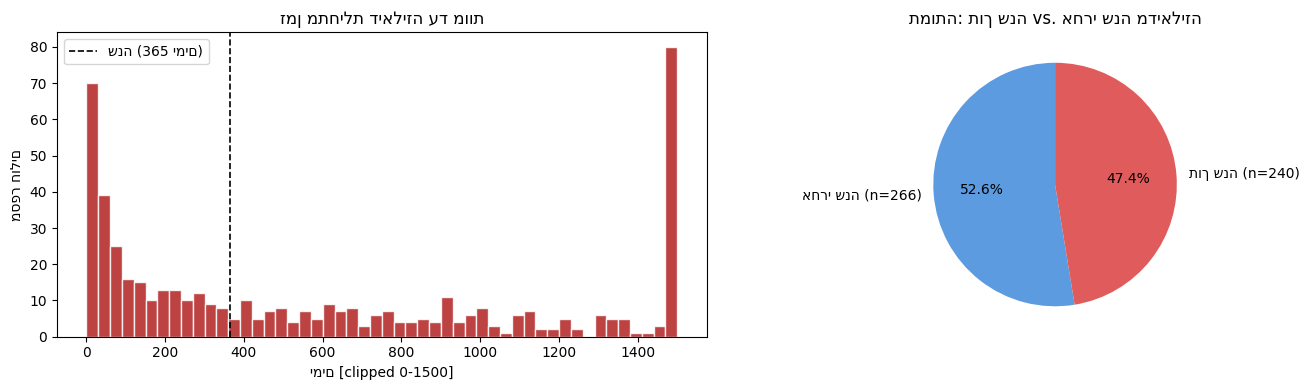

In [19]:
# ── טווח זמן מתחילת דיאליזה עד מוות ────────────────────────────────────────
valid_surv = died_with_dial['time_dial_to_death_days'].dropna()
valid_surv = valid_surv[valid_surv >= 0]

print('── סטטיסטיקות זמן דיאליזה → מוות (ימים) ──')
display(rich_numeric_summary(valid_surv))

med = valid_surv.median()
print(f'\nחציון  : {med:.0f} ימים  ({med/365:.1f} שנים)')
print(f'ממוצע  : {valid_surv.mean():.0f} ימים  ({valid_surv.mean()/365:.1f} שנים)')
print(f'טווח   : {valid_surv.min():.0f} – {valid_surv.max():.0f} ימים')

# ── ויזואליזציה ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(valid_surv.clip(0, 1500), bins=50,
             color='firebrick', edgecolor='white', alpha=0.85)
axes[0].axvline(365, color='black', linestyle='--', linewidth=1.2, label='שנה (365 ימים)')
axes[0].set_title('זמן מתחילת דיאליזה עד מוות')
axes[0].set_xlabel('ימים [clipped 0-1500]')
axes[0].set_ylabel('מספר חולים')
axes[0].legend()

def _classify(d):
    if pd.isna(d) or d < 0: return 'שגיאת נתונים'
    return 'תוך שנה' if d <= 365 else 'אחרי שנה'

slices = died_with_dial['time_dial_to_death_days'].apply(_classify).value_counts()
colors = ['#e05c5c' if 'תוך' in i else '#5c9be0' if 'אחרי' in i else '#cccccc'
          for i in slices.index]
axes[1].pie(slices, labels=[f'{i} (n={v})' for i, v in slices.items()],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('תמותה: תוך שנה vs. אחרי שנה מדיאליזה')

plt.tight_layout()
plt.show()

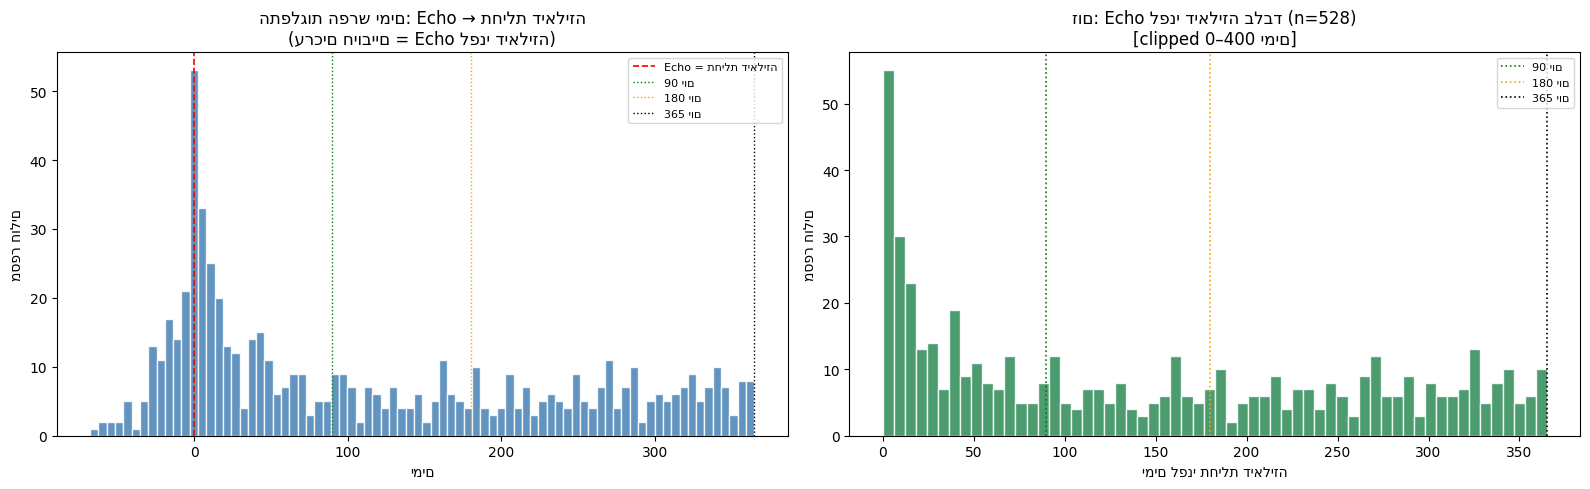

── כלל הנתונים (כולל שליליים) ──


,value
n,645.000000
mean,116.310078
std,125.108847
min,-68.000000
p01,-47.120000
p05,-22.800000
p10,-11.000000
p25,4.000000
median,69.000000
p75,226.000000



── רק Echo לפני דיאליזה (gap ≥ 0) ──


,value
n,528.000000
mean,145.884470
std,119.353206
min,0.000000
p01,0.000000
p05,2.000000
p10,6.000000
p25,29.000000
median,125.000000
p75,253.750000



── שכיחות לפי חלון זמן ──


,n,%_מסך_הדאטה,%_מתוך_עם_echo
gap_echo_to_dial_days,,,
אחרי דיאליזה,130,20.2,20.2
0–30d,122,18.9,18.9
31–60d,54,8.4,8.4
61–90d,35,5.4,5.4
91–180d,95,14.7,14.7
181–365d,209,32.4,32.4
>365d,0,0.0,0.0


In [20]:
# ── התפלגות הזמן בין Echo לתחילת דיאליזה ────────────────────────────────────
gap = df['gap_echo_to_dial_days'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── היסטוגרמה מלאה (כולל שליליים) ──────────────────────────────────────────
axes[0].hist(gap.clip(-365, 730), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0,   color='red',   linestyle='--', linewidth=1.2, label='Echo = תחילת דיאליזה')
axes[0].axvline(90,  color='green', linestyle=':',  linewidth=1,   label='90 יום')
axes[0].axvline(180, color='orange',linestyle=':',  linewidth=1,   label='180 יום')
axes[0].axvline(365, color='black', linestyle=':',  linewidth=1,   label='365 יום')
axes[0].set_title('התפלגות הפרש ימים: Echo → תחילת דיאליזה\n(ערכים חיוביים = Echo לפני דיאליזה)')
axes[0].set_xlabel('ימים')
axes[0].set_ylabel('מספר חולים')
axes[0].legend(fontsize=8)

# ── zoom: רק Echo לפני דיאליזה (gap ≥ 0) ───────────────────────────────────
gap_pos = gap[gap >= 0]
axes[1].hist(gap_pos.clip(0, 400), bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(90,  color='green', linestyle=':', linewidth=1.2, label='90 יום')
axes[1].axvline(180, color='orange',linestyle=':', linewidth=1.2, label='180 יום')
axes[1].axvline(365, color='black', linestyle=':', linewidth=1.2, label='365 יום')
axes[1].set_title(f'זום: Echo לפני דיאליזה בלבד (n={len(gap_pos)})\n[clipped 0–400 ימים]')
axes[1].set_xlabel('ימים לפני תחילת דיאליזה')
axes[1].set_ylabel('מספר חולים')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── סטטיסטיקות מלוות ─────────────────────────────────────────────────────────
print('── כלל הנתונים (כולל שליליים) ──')
display(rich_numeric_summary(gap))

print('\n── רק Echo לפני דיאליזה (gap ≥ 0) ──')
display(rich_numeric_summary(gap_pos))

# ── טבלת חלונות ──────────────────────────────────────────────────────────────
print('\n── שכיחות לפי חלון זמן ──')
bins   = [-np.inf, 0, 30, 60, 90, 180, 365, np.inf]
labels = ['אחרי דיאליזה', '0–30d', '31–60d', '61–90d', '91–180d', '181–365d', '>365d']
tbl = pd.cut(gap, bins=bins, labels=labels, right=True).value_counts(sort=False).to_frame('n')
tbl['%_מסך_הדאטה'] = (tbl['n'] / len(df) * 100).round(1)
tbl['%_מתוך_עם_echo'] = (tbl['n'] / gap.notna().sum() * 100).round(1)
display(tbl)

מספר מקרים שבהם Echo בוצע אחרי תחילת דיאליזה: 117
מתוך סך הנתונים: 645  (18.1%)

── סטטיסטיקות (ימים מתחילת דיאליזה עד Echo) ──


,value
n,117.000000
mean,17.153846
std,15.236422
min,1.000000
p01,1.000000
p05,1.000000
p10,2.000000
p25,5.000000
median,14.000000
p75,26.000000



חציון : 14 ימים  (0.5 חודשים)
ממוצע : 17 ימים  (0.6 חודשים)
טווח  : 1 – 68 ימים

── שכיחות לפי חלון זמן (ימים מתחילת דיאליזה עד Echo) ──


,n,%_מתוך_קבוצה,%_מסך_הדאטה
gap_echo_to_dial_days,,,
0–30d,99,84.6,15.3
31–60d,17,14.5,2.6
61–90d,1,0.9,0.2
91–180d,0,0.0,0.0
181–365d,0,0.0,0.0
>365d,0,0.0,0.0


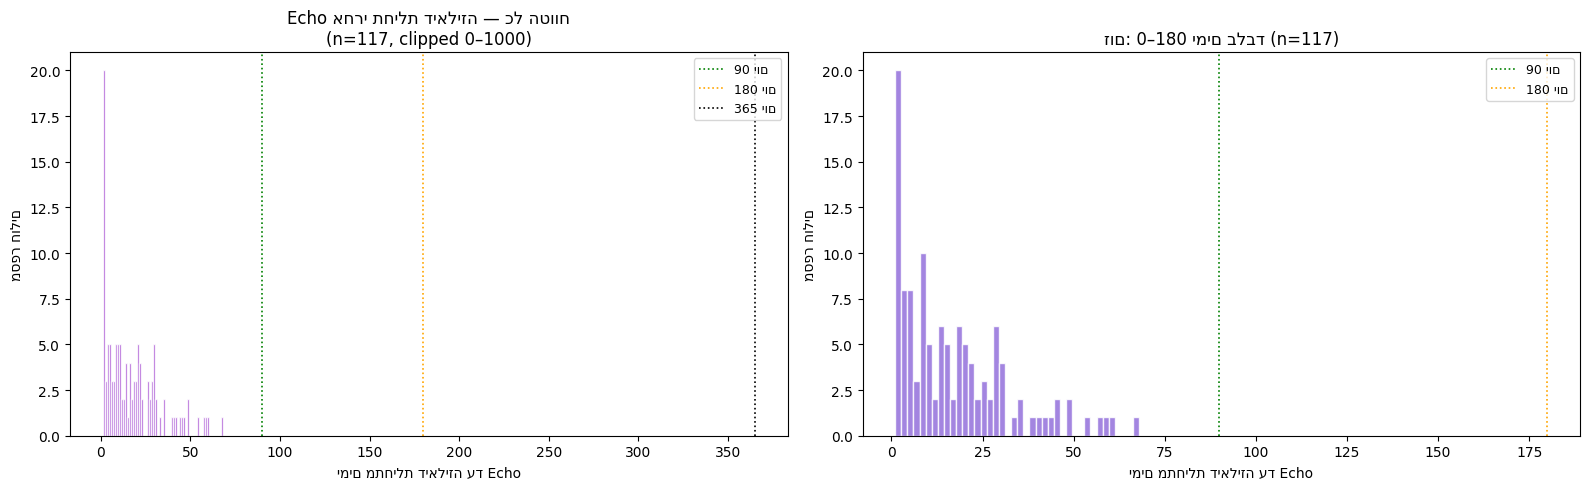

In [21]:
# ── Echo אחרי תחילת דיאליזה בלבד (gap < 0) ──────────────────────────────────
gap_neg = df['gap_echo_to_dial_days'].dropna()
gap_neg = gap_neg[gap_neg < 0]

# הופכים לחיובי להצגה: כמה ימים אחרי תחילת דיאליזה בוצע ה-Echo
days_after_dial = gap_neg.abs()

print(f'מספר מקרים שבהם Echo בוצע אחרי תחילת דיאליזה: {len(days_after_dial)}')
print(f'מתוך סך הנתונים: {len(df)}  ({len(days_after_dial)/len(df)*100:.1f}%)')

# ── סטטיסטיקות ───────────────────────────────────────────────────────────────
print('\n── סטטיסטיקות (ימים מתחילת דיאליזה עד Echo) ──')
display(rich_numeric_summary(days_after_dial))

med = days_after_dial.median()
print(f'\nחציון : {med:.0f} ימים  ({med/30.44:.1f} חודשים)')
print(f'ממוצע : {days_after_dial.mean():.0f} ימים  ({days_after_dial.mean()/30.44:.1f} חודשים)')
print(f'טווח  : {days_after_dial.min():.0f} – {days_after_dial.max():.0f} ימים')

# ── טבלת חלונות ──────────────────────────────────────────────────────────────
print('\n── שכיחות לפי חלון זמן (ימים מתחילת דיאליזה עד Echo) ──')
bins   = [0, 30, 60, 90, 180, 365, np.inf]
labels = ['0–30d', '31–60d', '61–90d', '91–180d', '181–365d', '>365d']
tbl = pd.cut(days_after_dial, bins=bins, labels=labels, right=True)\
        .value_counts(sort=False).to_frame('n')
tbl['%_מתוך_קבוצה'] = (tbl['n'] / len(days_after_dial) * 100).round(1)
tbl['%_מסך_הדאטה']  = (tbl['n'] / len(df) * 100).round(1)
display(tbl)

# ── היסטוגרמה ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# כל הטווח
axes[0].hist(days_after_dial.clip(0, 1000), bins=60,
             color='darkorchid', edgecolor='white', alpha=0.85)
axes[0].axvline(90,  color='green',  linestyle=':', linewidth=1.2, label='90 יום')
axes[0].axvline(180, color='orange', linestyle=':', linewidth=1.2, label='180 יום')
axes[0].axvline(365, color='black',  linestyle=':', linewidth=1.2, label='365 יום')
axes[0].set_title(f'Echo אחרי תחילת דיאליזה — כל הטווח\n(n={len(days_after_dial)}, clipped 0–1000)')
axes[0].set_xlabel('ימים מתחילת דיאליזה עד Echo')
axes[0].set_ylabel('מספר חולים')
axes[0].legend(fontsize=9)

# zoom: עד 180 יום
axes[1].hist(days_after_dial[days_after_dial <= 180], bins=40,
             color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(90,  color='green',  linestyle=':', linewidth=1.2, label='90 יום')
axes[1].axvline(180, color='orange', linestyle=':', linewidth=1.2, label='180 יום')
n_zoom = (days_after_dial <= 180).sum()
axes[1].set_title(f'זום: 0–180 ימים בלבד (n={n_zoom})')
axes[1].set_xlabel('ימים מתחילת דיאליזה עד Echo')
axes[1].set_ylabel('מספר חולים')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Save outputs

In [22]:
drop_df.to_csv(f"{DRIVE_BASE}/candidate_drops_echo_model.csv", index=False)

output_cols = (
    [COL_PATIENT, COL_DIAL, COL_ECHO, COL_DEATH,
     "gap_echo_to_dial_days", "death_event",
     "time_to_event_or_censor_days", "gap_bin",
     "keep_for_echo_model"]
    + flag_cols
)
df[output_cols].to_csv(f"{DRIVE_BASE}/date_eda_with_flags.csv", index=False)

print("✅ הקבצים נשמרו ל-Drive:")
print(f"  {DRIVE_BASE}/candidate_drops_echo_model.csv")
print(f"  {DRIVE_BASE}/date_eda_with_flags.csv")

✅ הקבצים נשמרו ל-Drive:
  /content/drive/MyDrive/dialysis/data/candidate_drops_echo_model.csv
  /content/drive/MyDrive/dialysis/data/date_eda_with_flags.csv


In [24]:
# ── סקירת כל העמודות הקטגוריאליות ───────────────────────────────────────────

# זיהוי אוטומטי של עמודות קטגוריאליות:
# object, category, bool — ועמודות נומריות עם מעט ערכים ייחודיים (עד 20)
cat_cols = [
    c for c in df.columns
    if df[c].dtype in ['object', 'category', 'bool']
    or (df[c].dtype not in ['datetime64[ns]', 'float64', 'int64']
        and df[c].nunique(dropna=True) <= 20)
]

# אפשר להוסיף ידנית עמודות נומריות שהן בעצם קטגוריאליות:
# cat_cols += ['some_numeric_flag_col']

print(f'נמצאו {len(cat_cols)} עמודות קטגוריאליות:\n{cat_cols}\n')
print('=' * 65)

for col in cat_cols:
    total = len(df)
    null_n = df[col].isna().sum()
    null_pct = null_n / total * 100

    # ספירת ערכים כולל NaN
    counts = df[col].value_counts(dropna=False).to_frame('n')
    counts['%'] = (counts['n'] / total * 100).round(1)
    counts.index = counts.index.astype(str).str.replace('<NA>', 'NULL').str.replace('nan', 'NULL')
    counts.index.name = 'ערך'

    print(f'\n── {col}  (ייחודיים: {df[col].nunique(dropna=True)} | NULL: {null_n} = {null_pct:.1f}%) ──')
    display(counts)
    print('-' * 65)

נמצאו 30 עמודות קטגוריאליות:
['HD/PD', 'm/f', 'LeftVentricleCavitySize', 'LeftVentricleWallThickness', 'LeftVentricleSystolicFunction', 'LeftVentricleSummary', 'RVSize', 'RVSystolicFunction', 'LACavitySize', 'AorticValveStructure', 'AorticValveRegurgitation', 'AorticValveSummary', 'MitralValveStructure', 'MitralRegurgitation', 'MitralValveSummary', 'TricuspidValveStructure', 'TricuspidRegurgitation', 'ECHO_SPAP', 'ProcedureSummary', 'MI', 'OncologicalDiagnosis', 'flag_missing_dialysis_start', 'flag_missing_echo_date', 'flag_echo_after_dialysis', 'flag_echo_more_than_12m_before', 'flag_death_before_dialysis', 'flag_death_before_echo', 'flag_followup_negative', 'gap_bin', 'keep_for_echo_model']


── HD/PD  (ייחודיים: 3 | NULL: 0 = 0.0%) ──


,n,%
ערך,,
HD,512,79.4
PD,132,20.5
HD,1,0.2


-----------------------------------------------------------------

── m/f  (ייחודיים: 3 | NULL: 1 = 0.2%) ──


,n,%
ערך,,
m,446,69.1
f,197,30.5
NULL,1,0.2
m,1,0.2


-----------------------------------------------------------------

── LeftVentricleCavitySize  (ייחודיים: 6 | NULL: 29 = 4.5%) ──


...

-----------------------------------------------------------------

── gap_bin  (ייחודיים: 4 | NULL: 0 = 0.0%) ──


,n,%
ערך,,
0–90d,211,32.7
181–365d,209,32.4
echo after dialysis (<0),130,20.2
91–180d,95,14.7
>365d,0,0.0


-----------------------------------------------------------------

── keep_for_echo_model  (ייחודיים: 2 | NULL: 0 = 0.0%) ──


,n,%
ערך,,
True,528,81.9
False,117,18.1


-----------------------------------------------------------------


סה"כ שורות: 645
סה"כ עמודות עם חסרים: 59

                                               missing_count  missing_pct
COPD                                                    540         83.7
CABG                                                    512         79.4
AorticValveSummary                                      507         78.6
OncologicalDiagnosis                                    502         77.8
MI                                                      452         70.1
LeftVentricleSummary                                    450         69.8
MitralValveSummary                                      443         68.7
AFIB                                                    342         53.0
DYSLIPIDEMIA                                            334         51.8
IHD                                                     249         38.6
Diabetes mellitus                                       235         36.4
TricuspidValveStructure                                 235         36.4
TissueDo

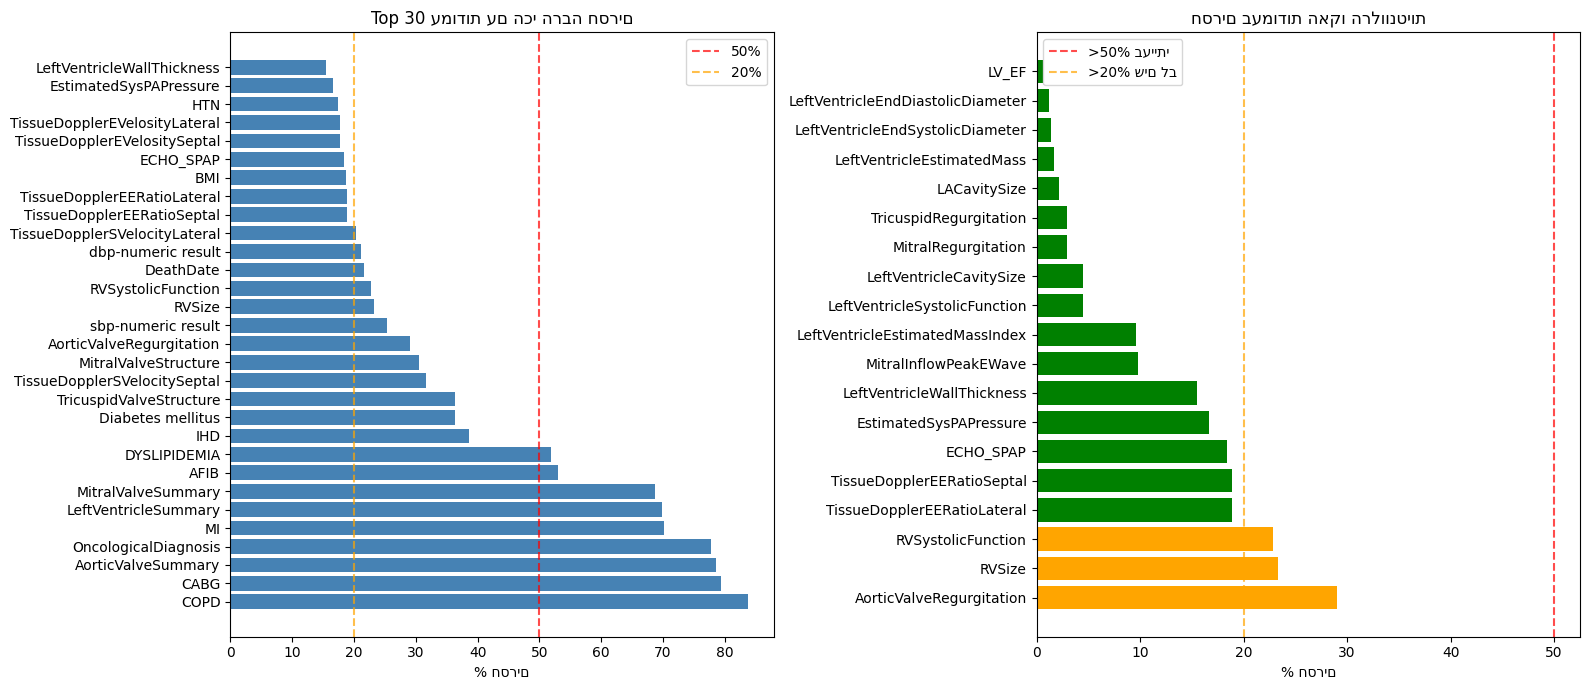


===== % חסרים לפי סוג דיאליזה =====
LeftVentricleWallThickness: HD=16.0%  |  PD=12.9%
RVSize: HD=24.8%  |  PD=17.4%
RVSystolicFunction: HD=24.8%  |  PD=15.2%
ECHO_SPAP: HD=18.9%  |  PD=16.7%
EstimatedSysPAPressure: HD=17.8%  |  PD=12.9%
AorticValveRegurgitation: HD=29.1%  |  PD=28.8%
TissueDopplerEERatioSeptal: HD=17.2%  |  PD=25.8%
TissueDopplerEERatioLateral: HD=17.4%  |  PD=25.0%
MitralInflowPeakEWave: HD=9.4%  |  PD=11.4%
LeftVentricleEstimatedMassIndex: HD=10.7%  |  PD=5.3%

===== סיכום החלטות =====
LV_EF: 0.6%  →  ✅ השתמש ישירות
LeftVentricleSystolicFunction: 4.5%  →  ✅ השתמש ישירות
LeftVentricleCavitySize: 4.5%  →  ✅ השתמש ישירות
LeftVentricleWallThickness: 15.5%  →  ✅ השתמש ישירות
RVSize: 23.3%  →  ⚠️  שקול imputation או חילוץ מטקסט
RVSystolicFunction: 22.8%  →  ⚠️  שקול imputation או חילוץ מטקסט
LACavitySize: 2.2%  →  ✅ השתמש ישירות
ECHO_SPAP: 18.4%  →  ✅ השתמש ישירות
EstimatedSysPAPressure: 16.7%  →  ✅ השתמש ישירות
MitralRegurgitation: 2.9%  →  ✅ השתמש ישירות
TricuspidRegurg

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ========== 1. סיכום חסרים כללי ==========
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print(f"סה\"כ שורות: {len(df)}")
print(f"סה\"כ עמודות עם חסרים: {len(missing)}")
print("\n", missing.to_string())

# ========== 2. התמקדות בעמודות האקו הרלוונטיות ==========
echo_cols = [
    'LV_EF',
    'LeftVentricleSystolicFunction',
    'LeftVentricleCavitySize',
    'LeftVentricleWallThickness',
    'RVSize',
    'RVSystolicFunction',
    'LACavitySize',
    'ECHO_SPAP',
    'EstimatedSysPAPressure',
    'MitralRegurgitation',
    'TricuspidRegurgitation',
    'AorticValveRegurgitation',
    'TissueDopplerEERatioSeptal',
    'TissueDopplerEERatioLateral',
    'MitralInflowPeakEWave',
    'LeftVentricleEndDiastolicDiameter',
    'LeftVentricleEndSystolicDiameter',
    'LeftVentricleEstimatedMass',
    'LeftVentricleEstimatedMassIndex',
]

# רק עמודות שקיימות בפועל בקובץ
echo_cols_existing = [c for c in echo_cols if c in df.columns]

echo_missing = pd.DataFrame({
    'missing_count': df[echo_cols_existing].isnull().sum(),
    'missing_pct': (df[echo_cols_existing].isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print("\n===== חסרים בעמודות האקו =====")
print(echo_missing.to_string())

# ========== 3. ויזואליזציה ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# גרף 1: כל העמודות
top_missing = missing.head(30)
axes[0].barh(top_missing.index, top_missing['missing_pct'], color='steelblue')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50%')
axes[0].axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20%')
axes[0].set_xlabel('% חסרים')
axes[0].set_title('Top 30 עמודות עם הכי הרבה חסרים')
axes[0].legend()

# גרף 2: עמודות אקו בלבד
axes[1].barh(echo_missing.index, echo_missing['missing_pct'],
             color=['red' if x > 50 else 'orange' if x > 20 else 'green'
                    for x in echo_missing['missing_pct']])
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.7, label='>50% בעייתי')
axes[1].axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='>20% שים לב')
axes[1].set_xlabel('% חסרים')
axes[1].set_title('חסרים בעמודות האקו הרלוונטיות')
axes[1].legend()

plt.tight_layout()
plt.savefig('missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 4. האם חסרים קשורים לסוג דיאליזה (HD/PD)? ==========
if 'HD/PD' in df.columns:
    print("\n===== % חסרים לפי סוג דיאליזה =====")
    for col in echo_cols_existing:
        hd_miss = df[df['HD/PD'] == 'HD'][col].isnull().mean() * 100
        pd_miss = df[df['HD/PD'] == 'PD'][col].isnull().mean() * 100
        if hd_miss > 10 or pd_miss > 10:
            print(f"{col}: HD={hd_miss:.1f}%  |  PD={pd_miss:.1f}%")

# ========== 5. סיכום מהיר לקבלת החלטות ==========
print("\n===== סיכום החלטות =====")
for col in echo_cols_existing:
    pct = echo_missing.loc[col, 'missing_pct']
    if pct < 20:
        status = "✅ השתמש ישירות"
    elif pct < 50:
        status = "⚠️  שקול imputation או חילוץ מטקסט"
    else:
        status = "❌ חסר מדי — חלץ מProcedureSummary"
    print(f"{col}: {pct}%  →  {status}")

In [7]:
import re
import pandas as pd

def extract_rv_size(text):
    if pd.isna(text):
        return None
    if re.search(r'חדר ימין.{0,30}(מורחב|מוגדל)', text):
        return 'enlarged'
    if re.search(r'חדר ימין.{0,30}תקין', text):
        return 'normal'
    return None

def extract_rv_function(text):
    if pd.isna(text):
        return None
    if re.search(r'חדר ימין.{0,40}(ירוד.{0,15}קשה|קשה.{0,15}ירוד)', text):
        return 'severely_reduced'
    if re.search(r'חדר ימין.{0,40}(ירוד.{0,15}בינונ|בינונ.{0,15}ירוד|היפוקינטי)', text):
        return 'moderately_reduced'
    if re.search(r'חדר ימין.{0,40}(ירוד.{0,15}קל|קל.{0,15}ירוד)', text):
        return 'mildly_reduced'
    if re.search(r'חדר ימין.{0,40}תפקוד תקין', text):
        return 'normal'
    return None

def extract_aortic_regurgitation(text):
    if pd.isna(text):
        return None
    # סדר חשוב — מהחמור לקל
    if re.search(r'(דלף|אי ספיקה).{0,20}אאורט.{0,20}(קשה|חמור)', text):
        return 'severe'
    if re.search(r'(דלף|אי ספיקה).{0,20}אאורט.{0,20}בינונ', text):
        return 'moderate'
    if re.search(r'(דלף|אי ספיקה).{0,20}אאורט.{0,20}קל', text):
        return 'mild'
    if re.search(r'(דלף|אי ספיקה).{0,20}אאורט.{0,20}מינימל', text):
        return 'minimal'
    if re.search(r'מסתם אאורט.{0,30}ללא דלף', text):
        return 'none'
    return None

# הרצה
df['rv_size_extracted'] = df['ProcedureSummary'].apply(extract_rv_size)
df['rv_function_extracted'] = df['ProcedureSummary'].apply(extract_rv_function)
df['aortic_regurg_extracted'] = df['ProcedureSummary'].apply(extract_aortic_regurgitation)

# בדיקת כמה הצלחנו לחלץ
for col in ['rv_size_extracted', 'rv_function_extracted', 'aortic_regurg_extracted']:
    success = df[col].notna().sum()
    print(f"{col}: חולצו {success} מתוך {len(df)} ({success/len(df)*100:.1f}%)")

rv_size_extracted: חולצו 287 מתוך 645 (44.5%)
rv_function_extracted: חולצו 134 מתוך 645 (20.8%)
aortic_regurg_extracted: חולצו 79 מתוך 645 (12.2%)


In [10]:
# שלב אבחון — הבן למה הרגקס נכשל

# 1. בדוק שורות שלא חולצו — מה כתוב שם?
not_extracted_rv = df[df['rv_function_extracted'].isna() &
                       df['ProcedureSummary'].notna()]

print("=== דוגמאות לטקסט שלא חולץ RV Function ===")
for text in not_extracted_rv['ProcedureSummary'].sample(20):
    # חפש רק את החלק הרלוונטי
    match = re.search(r'חדר ימין.{0,80}', text)
    if match:
        print(">>>", match.group(), "\n")

# 2. בדוק שורות שלא חולצו אאורטלית
not_extracted_ao = df[df['aortic_regurg_extracted'].isna() &
                       df['ProcedureSummary'].notna()]

print("\n=== דוגמאות לטקסט שלא חולץ Aortic Regurg ===")
for text in not_extracted_ao['ProcedureSummary'].sample(20):
    match = re.search(r'(אאורט|מסתם).{0,80}', text)
    if match:
        print(">>>", match.group(), "\n")

# 3. הבן את ההתפלגות של מה שכן חולץ
print("\n=== התפלגות RV Function שחולץ ===")
print(df['rv_function_extracted'].value_counts())

print("\n=== התפלגות Aortic Regurg שחולץ ===")
print(df['aortic_regurg_extracted'].value_counts())

# 4. בדוק כמה שורות יש בהן בכלל מילה רלוונטית
rv_mentioned = df['ProcedureSummary'].str.contains('חדר ימין', na=False).sum()
ao_mentioned = df['ProcedureSummary'].str.contains('אאורט', na=False).sum()

print(f"\nשורות שמוזכר בהן חדר ימין: {rv_mentioned}")
print(f"שורות שמוזכר בהן אאורטלי: {ao_mentioned}")
print(f"אבל חולץ RV function רק מ: {df['rv_function_extracted'].notna().sum()}")
print(f"אבל חולץ אאורטלי רק מ: {df['aortic_regurg_extracted'].notna().sum()}")

=== דוגמאות לטקסט שלא חולץ RV Function ===
>>> חדר ימין בגודל ותפקוד תקינים, הרחבה קלה של עליה שמאלית, מסתם אורטלי מסוייד עם דלף קל-בינ 

>>> חדר ימין מורחב במעט עם ירידה בינונית עד קשה בתיפקודו. מסתם אורטלי מעובה עם דליפה קלה. מס 

>>> חדר ימין תקין בגודלו ותפקודו. עלי מסתם מטראלי סקלרוטים קל, רושם לאפקט tethering  עם אי ס 

>>> חדר ימין בגודל ותפקוד תקינים ,לא ניתן להעריך ל"ד ריאתי בהעדר סיגנל TR מסתם אאורטלי במבנה 

>>> חדר ימין ברוחב ותפקוד שמור. פרוזדורים ברוחב תקין. הודגם דלף אאורטלי קל-בינוני. דלף מיטרל 

>>> חדר ימין בגודל ותפקוד תקינים עליה שמאלית ברוחב תקין מסתם אאורטלי מסוייד עם דלף מנימלי לל 

>>> חדר ימין תקין. מסתם אורטלי מעובה ומסוייד עם דליפה קלה עד בינונית. מסתם מיטרלי עם רסטריקצ 

>>> חדר ימין בגודל תקין, התכווצותו מופחתת קל, עליה ימין מוגדלת קל. בעמדה אאורטלית מסתם תותב  

>>> חדר ימין תקין, מסתם אאורטלי מעט מסוייד, טבעת המסתם המיטרלי מסויידת, אי ספיקה מיטרלית קלה 


=== דוגמאות לטקסט שלא חולץ Aortic Regurg ===
>>> מסתם אאורטלי תותב ביולוגי עם תפקוד תקין. מסתם מיטרלי

In [ ]:
import google.generativeai as genai
import json
import time
import pandas as pd

from google.colab import userdata

genai.configure(api_key=userdata.get("GOOGLE_API_KEY"))
model = genai.GenerativeModel("gemini-2.0-flash")

def extract_echo_features_gemini(text, patient_id):
    if pd.isna(text) or text.strip() == '':
        return None

    prompt = f"""אתה קרדיולוג מומחה בקריאת דוחות אקוקרדיוגרפיה בעברית.
חלץ מהטקסט את הערכים הבאים. החזר JSON בלבד — ללא טקסט נוסף.

## כללים חשובים:
1. **rv_function** — תפקוד חדר ימין (לא גודל!):
   - "חדר ימין תקין" / "חדר ימין בגודל ותפקוד תקין" / "התכווצות תקינה" → "normal"
   - "ירוד במידה קלה" / "מופחת קל" → "mildly_reduced"
   - "היפוקינטי" / "ירוד במידה בינונית" / "מופחת בינוני" → "moderately_reduced"
   - "ירוד במידה קשה" / "מופחת קשה" → "severely_reduced"
   - אם כתוב רק "חדר ימין תקין" בלי פירוט נוסף — זה **normal** (לא null!)
   - null רק אם חדר ימין לא מוזכר כלל בטקסט

2. **rv_size** — גודל חדר ימין:
   - "חדר ימין תקין" / "בגודל תקין" → "normal"
   - "מורחב" / "מוגדל" → "enlarged"
   - null רק אם גודל חדר ימין לא מוזכר כלל

3. **aortic_regurgitation** — אי ספיקה / דלף אורטלי (אאורטלי):
   - אם לא מוזכר כלל → "none"
   - "מינימלי/ת" → "minimal"
   - "קל/ה" → "mild"
   - "קל/ה עד בינוני/ת" → "mild_moderate"
   - "בינוני/ת" → "moderate"
   - "קשה / חמור" → "severe"
   - מסתם מלאכותי / TAVI → "prosthetic"

4. **aortic_stenosis** — הצרות / היצרות אורטלית:
   - אם לא מוזכרת הצרות → "none"
   - "הצרות קלה" → "mild"
   - "הצרות קלה עד בינונית" / "קלה לבינונית" → "mild_moderate"
   - "הצרות בינונית" → "moderate"
   - "הצרות קשה" → "severe"

5. **diastolic_pattern** — תבנית מילוי דיאסטולית:
   - "תבנית מילוי תקינה" → "normal"
   - "הפרעה ברלקסציה" / "grade 1" → "grade1"
   - "פסאודונורמלית" / "פסאודו-נורמלית" / "פסאודו תקינה" / "פסודו-תקינה" → "pseudonormal"
   - "רסטריקטיבית" → "restrictive"
   - null רק אם תבנית מילוי לא מוזכרת כלל

6. **pericardial_effusion** — תפליט / נוזל פריקרדיאלי:
   - אם לא מוזכר כלל → "none"
   - "מינימלי" / "כמות קטנה" → "mild"
   - "בינוני" → "moderate"
   - "גדול" / "רב" → "large"

7. **tamponade_signs** — סימני טמפונדה / לחץ על חדרים ימניים:
   - אם לא מוזכר או "ללא סימני לחץ" → "no"
   - אם יש עדות → "yes"

8. **pleural_effusion** — תפליט פלאורלי / נוזל פלאורלי:
   - אם לא מוזכר כלל → "no"
   - אם מוזכר תפליט פלאורלי / נוזל פלאורלי / מיימת → "yes"

9. **pacemaker** — קוצב לב / אלקטרודה:
   - אם לא מוזכר → "no"
   - "אלקטרודת קוצב" / "קוצב" → "yes"

## דוגמאות:

טקסט: "חדר ימין תקין. עליה שמאלית מורחבת. אי ספיקה מיטרלית קלה."
→ {{"rv_function": "normal", "rv_size": "normal", "aortic_regurgitation": "none", "aortic_stenosis": "none", "diastolic_pattern": null, "pericardial_effusion": "none", "tamponade_signs": "no", "pleural_effusion": "no", "pacemaker": "no"}}

טקסט: "חדר ימין מורחב במידה קלה תפקודו שמור. תבנית המילוי פסאודונורמלית. אי ספיקה אורטלית מינימלית. הודגם נוזל פריקרדיאלי בכמות מינימלית."
→ {{"rv_function": "normal", "rv_size": "enlarged", "aortic_regurgitation": "minimal", "aortic_stenosis": "none", "diastolic_pattern": "pseudonormal", "pericardial_effusion": "mild", "tamponade_signs": "no", "pleural_effusion": "no", "pacemaker": "no"}}

טקסט: "חדר ימין מורחב והיפוקינטי עם אלקטרודת קוצב. מסתם אורטלי מסוייד עם הצרות בינונית ודלף קל. תפליט פלאורלי משמאל."
→ {{"rv_function": "moderately_reduced", "rv_size": "enlarged", "aortic_regurgitation": "mild", "aortic_stenosis": "moderate", "diastolic_pattern": null, "pericardial_effusion": "none", "tamponade_signs": "no", "pleural_effusion": "yes", "pacemaker": "yes"}}

## הטקסט לחילוץ:
{text}

החזר JSON בלבד:"""

    try:
        response = model.generate_content(prompt)

        # נקה את התשובה למקרה שיש markdown
        raw = response.text.strip()
        raw = raw.replace('```json', '').replace('```', '').strip()

        result = json.loads(raw)
        result['patient number'] = patient_id
        return result

    except json.JSONDecodeError:
        print(f"שגיאת JSON עבור חולה {patient_id}: {response.text[:100]}")
        return None
    except Exception as e:
        print(f"שגיאה עבור חולה {patient_id}: {e}")
        return None


# ריצת מדגם בדיקה על 20 שורות קודם
print("=== בדיקה על 20 שורות ===")
test_df = df.sample(20).reset_index(drop=True)
test_results = []

for idx, row in test_df.iterrows():
    result = extract_echo_features_gemini(
        row['ProcedureSummary'],
        row['patient number']
    )
    if result:
        test_results.append(result)
    time.sleep(0.3)

test_results_df = pd.DataFrame(test_results)
test_merged = test_df.merge(test_results_df, on='patient number', how='left')
test_merged[['ProcedureSummary', 'rv_function', 'rv_size',
             'aortic_regurgitation', 'diastolic_pattern',
             'pericardial_effusion', 'pleural_effusion']].to_excel('test_20_rows.xlsx', index=False)
print("בדוק test_20_rows.xlsx לפני שממשיכים")

In [ ]:
## ── Install extra libraries ───────────────────────────────────────
!pip install -q xgboost shap scikit-learn pyyaml

## Issue 1 — Data Cleaning & Binary Variables

In [ ]:
import json, os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

# ── Binary variables ──────────────────────────────────────────────
df['is_male'] = (df['m/f'].astype(str).str.strip().str.lower()
                  .map({'m': 1, 'male': 1, 'f': 0, 'female': 0,
                        'זכר': 1, 'נקבה': 0}))
df['is_hd'] = (df['HD/PD'].astype(str).str.strip().str.upper()
                .map({'HD': 1, 'PD': 0}))

# ── Comorbidities ─────────────────────────────────────────────────
COMORBIDITY_COLS = [
    'MI_binary', 'CABG_binary', 'IHD_binary', 'AFIB_binary',
    'HTN_binary', 'Diabetes mellitus_binary', 'DYSLIPIDEMIA_binary',
    'COPD_binary', 'OncologicalDiagnosis',
]
for col in COMORBIDITY_COLS:
    if col in df.columns:
        # Ensure binary: if not already 0/1, convert
        if df[col].dtype == object:
            df[col] = df[col].notna().astype(int)
        else:
            df[col] = df[col].fillna(0).clip(0, 1).astype(int)

avail_comorbidities = [c for c in COMORBIDITY_COLS if c in df.columns]
df['n_comorbidities'] = df[avail_comorbidities].sum(axis=1)
print(f"n_comorbidities built from {len(avail_comorbidities)} columns: {avail_comorbidities}")

# ── Remove rows without patient number ────────────────────────────
n_before = len(df)
df = df.dropna(subset=[CONFIG["COL_PATIENT"]]).copy()
n_no_id = n_before - len(df)

# ── Remove duplicate patients (keep first) ────────────────────────
n_before2 = len(df)
df = df.drop_duplicates(subset=[CONFIG["COL_PATIENT"]], keep='first').copy()
n_dupes = n_before2 - len(df)

# ── Report ────────────────────────────────────────────────────────
load_report = {
    "n_raw": n_before + n_no_id,
    "n_removed_no_id": n_no_id,
    "n_removed_duplicates": n_dupes,
    "n_clean": len(df),
    "is_male_pct": round(float(df['is_male'].mean()), 3),
    "is_hd_pct": round(float(df['is_hd'].mean()), 3),
    "n_comorbidities_mean": round(float(df['n_comorbidities'].mean()), 2),
    "comorbidity_columns_used": avail_comorbidities,
}
with open(f"{CONFIG['OUTPUT_DIR']}/data_loaded_report.json", "w") as f:
    json.dump(load_report, f, indent=2, ensure_ascii=False)
print(json.dumps(load_report, indent=2))

## Issue 2 — Cohort Building & Anchor

`build_cohort(df, config)` — defines anchor_date and applies inclusion/exclusion filters.

In [ ]:
def build_cohort(df, config):
    """
    Build analytic cohort based on ANCHOR_MODE.

    Echo mode:
      anchor_date = Echo_Date
      Require Echo_Date not missing
      Drop if DeathDate < Echo_Date

    Dialysis mode:
      anchor_date = Dialysis_Start_Date
      Require both dates present
      If ECHO_BEFORE_DIALYSIS_ONLY: require Echo_Date <= Dialysis_Start_Date
      Require gap_echo_to_dial_days <= ECHO_TO_DIALYSIS_WINDOW_DAYS
      Drop if DeathDate < Dialysis_Start_Date

    Returns (df_cohort, cohort_report_dict).
    """
    report = {"anchor_mode": config["ANCHOR_MODE"], "n_input": len(df), "exclusions": {}}
    cdf = df.copy()

    # Ensure gap column exists
    cdf["gap_echo_to_dial_days"] = (cdf[config["COL_DIAL"]] - cdf[config["COL_ECHO"]]).dt.days

    if config["ANCHOR_MODE"] == "echo":
        cdf["anchor_date"] = cdf[config["COL_ECHO"]]

        mask = cdf[config["COL_ECHO"]].isna()
        report["exclusions"]["missing_echo_date"] = int(mask.sum())
        cdf = cdf[~mask].copy()

        mask = cdf[config["COL_DEATH"]].notna() & (cdf[config["COL_DEATH"]] < cdf[config["COL_ECHO"]])
        report["exclusions"]["death_before_echo"] = int(mask.sum())
        cdf = cdf[~mask].copy()

    else:  # dialysis
        cdf["anchor_date"] = cdf[config["COL_DIAL"]]

        mask_dial = cdf[config["COL_DIAL"]].isna()
        mask_echo = cdf[config["COL_ECHO"]].isna()
        report["exclusions"]["missing_dialysis_date"] = int(mask_dial.sum())
        report["exclusions"]["missing_echo_date"] = int(mask_echo.sum())
        cdf = cdf[~mask_dial & ~mask_echo].copy()

        if config.get("ECHO_BEFORE_DIALYSIS_ONLY", True):
            mask = cdf["gap_echo_to_dial_days"] < 0
            report["exclusions"]["echo_after_dialysis"] = int(mask.sum())
            cdf = cdf[~mask].copy()

        window = config["ECHO_TO_DIALYSIS_WINDOW_DAYS"]
        mask = cdf["gap_echo_to_dial_days"] > window
        report["exclusions"][f"echo_outside_{window}d_window"] = int(mask.sum())
        cdf = cdf[~mask].copy()

        mask = cdf[config["COL_DEATH"]].notna() & (cdf[config["COL_DEATH"]] < cdf[config["COL_DIAL"]])
        report["exclusions"]["death_before_dialysis"] = int(mask.sum())
        cdf = cdf[~mask].copy()

    # Optional: exclude early deaths
    ed = config.get("EXCLUDE_EARLY_DEATH_DAYS")
    if ed is not None:
        time_to_death = (cdf[config["COL_DEATH"]] - cdf["anchor_date"]).dt.days
        mask = cdf[config["COL_DEATH"]].notna() & time_to_death.between(0, ed)
        report["exclusions"][f"early_death_le_{ed}d"] = int(mask.sum())
        cdf = cdf[~mask].copy()

    report["n_output"] = len(cdf)
    return cdf, report

# ── Execute ──────────────────────────────────────────────────────
df_cohort, cohort_report = build_cohort(df, CONFIG)
with open(f"{CONFIG['OUTPUT_DIR']}/cohort_report_{CONFIG['ANCHOR_MODE']}.json", "w") as f:
    json.dump(cohort_report, f, indent=2, ensure_ascii=False)
print(json.dumps(cohort_report, indent=2, ensure_ascii=False))

## Issue 3 — Target Creation (1-year mortality)

`make_target(df_cohort, config)`

In [ ]:
def make_target(df_cohort, config):
    """
    Create binary target: died within HORIZON_DAYS of anchor_date.

    If DeathDate exists:
      time_to_event = (DeathDate - anchor_date).days
      y = 1 if 0 <= time_to_event <= 365

    If no DeathDate:
      followup_days = (DATASET_END_DATE - anchor_date).days
      y = 0 if followup_days >= 365
      DROP if followup_days < 365 (insufficient follow-up)

    Returns (df_target, target_report_dict).
    """
    H = config["HORIZON_DAYS"]
    mdf = df_cohort.copy()

    # Compute dataset_end_date if not set
    dataset_end = config.get("DATASET_END_DATE")
    if dataset_end is None:
        dataset_end = pd.concat([
            mdf[config["COL_ECHO"]],
            mdf[config["COL_DIAL"]],
            mdf[config["COL_DEATH"]]
        ]).dropna().max()
        config["DATASET_END_DATE"] = dataset_end
    print(f"Dataset end date: {dataset_end}")

    def assign_target(row):
        anchor = row["anchor_date"]
        death = row[config["COL_DEATH"]]
        if pd.isna(anchor):
            return np.nan

        if pd.notna(death):
            tte = (death - anchor).days
            if tte < 0:
                return np.nan
            return 1 if tte <= H else 0
        else:
            followup = (dataset_end - anchor).days
            if followup >= H:
                return 0
            else:
                return np.nan  # insufficient follow-up

    mdf["target_1yr_death"] = mdf.apply(assign_target, axis=1)
    n_dropped = int(mdf["target_1yr_death"].isna().sum())
    mdf = mdf.dropna(subset=["target_1yr_death"]).copy()
    mdf["target_1yr_death"] = mdf["target_1yr_death"].astype(int)

    report = {
        "followup_mode": config["FOLLOWUP_MODE"],
        "dataset_end_date": str(dataset_end.date()) if hasattr(dataset_end, 'date') else str(dataset_end),
        "n_dropped_insufficient_followup": n_dropped,
        "n_final": len(mdf),
        "n_events": int(mdf["target_1yr_death"].sum()),
        "n_censored": int((mdf["target_1yr_death"] == 0).sum()),
        "event_rate": round(float(mdf["target_1yr_death"].mean()), 4),
    }
    return mdf, report

# ── Execute ──────────────────────────────────────────────────────
df_target, target_report = make_target(df_cohort, CONFIG)
with open(f"{CONFIG['OUTPUT_DIR']}/target_report_{CONFIG['ANCHOR_MODE']}.json", "w") as f:
    json.dump(target_report, f, indent=2, ensure_ascii=False)
print(json.dumps(target_report, indent=2, ensure_ascii=False))

## Issue 4+5 — Feature Definitions: Baseline & Echo Raw

Exact feature lists as specified in the protocol.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# FEATURE SET DEFINITIONS — hardcoded per protocol
# ══════════════════════════════════════════════════════════════════

BASELINE_SMALL = [
    "AgeAtFirstHFDate",
    "is_male",
    "is_hd",
    "hospitalization-count",
    "n_comorbidities",
    "albumin-numeric result",
    "hb-numeric result",
    "crp-numeric result",
    "creatinine-numeric result",
]

ECHO_RAW = [
    # LV
    "LV_EF",
    "LeftVentricleEndDiastolicDiameter",
    "LeftVentricleEndSystolicDiameter",
    "LeftVentricleInterventricularSeptumThickness",
    "LeftVentriclePosteriorWallThickness",
    "LeftVentricleEstimatedMassIndex",
    "LeftVentricleSystolicFunction_ord",
    "LeftVentricleCavitySize_ord",
    "LeftVentricleWallThickness_ord",
    "LeftVentricleScoreIndex",
    # Diastolic
    "MitralInflowPeakEWave",
    "TissueDopplerEVelositySeptal",
    "TissueDopplerEERatioSeptal",
    "TissueDopplerEVelosityLateral",
    "TissueDopplerEERatioLateral",
    # Derived diastolic
    "avg_E_e_ratio",
    "avg_e_prime",
    # Pulmonary pressure
    "EstimatedSysPAPressure",
    # RV (mandatory)
    "RVSize_ord",
    "RVSystolicFunction_ord",
    # Valves
    "MitralRegurgitation_ord",
    "TricuspidRegurgitation_ord",
    "AorticValveRegurgitation_ord",
    # LA
    "LACavitySize_ord",
]

CONSTRUCTS = [
    "lv_systolic_severity",
    "lvh_binary",
    "diastolic_burden",
    "phtn_severity",
    "right_heart_burden_score",
    "valve_burden_max",
]

# ── 5 model specifications ────────────────────────────────────────
MODEL_SPECS = {
    "M0": {"label": "Baseline-Small",          "features": BASELINE_SMALL},
    "M1A": {"label": "Echo-Raw",               "features": ECHO_RAW},
    "M1B": {"label": "Constructs",             "features": CONSTRUCTS},
    "M2A": {"label": "Baseline + Echo-Raw",    "features": BASELINE_SMALL + ECHO_RAW},
    "M2B": {"label": "Baseline + Constructs",  "features": BASELINE_SMALL + CONSTRUCTS},
}

for name, spec in MODEL_SPECS.items():
    print(f"  {name} ({spec['label']}): {len(spec['features'])} features defined")

## Issue 5b — Ordinal Encoding & Preprocessing

`build_preprocessor(df_in, config)` — ordinal encoding, derived variables.

In [ ]:
def build_preprocessor(df_in, config):
    """
    Ordinal encoding for categorical echo features.
    Creates _ord columns + derived echo variables.
    Saves category_mapping.json.
    Returns (df_processed, ordinal_maps).
    """
    mdf = df_in.copy()

    ORDINAL_MAPS = {
        'LeftVentricleCavitySize': {
            'תקין': 0, 'normal': 0,
            'מורחב במידה קלה': 1, 'mildly dilated': 1,
            'מורחב במידה בינונית': 2, 'moderately dilated': 2,
            'מורחב במידה קשה': 3, 'severely dilated': 3,
            'מורחב': 2,
        },
        'LeftVentricleWallThickness': {
            'תקין': 0, 'normal': 0,
            'מעובה במידה קלה': 1,
            'מעובה במידה בינונית': 2, 'היפרטרופי': 2,
            'מעובה במידה קשה': 3, 'מעובה': 2,
        },
        'LeftVentricleSystolicFunction': {
            'תקין': 0, 'normal': 0, 'שמור': 0,
            'ירוד במידה קלה': 1, 'mildly reduced': 1,
            'ירוד במידה קלה עד בינונית': 1.5,
            'ירוד במידה בינונית': 2, 'moderately reduced': 2,
            'ירוד במידה בינונית עד קשה': 2.5,
            'ירוד במידה קשה': 3, 'severely reduced': 3,
        },
        'LACavitySize': {
            'תקין': 0, 'normal': 0,
            'מורחב במידה קלה': 1, 'מוגדל במידה קלה': 1,
            'מורחב במידה בינונית': 2, 'מוגדל במידה בינונית': 2,
            'מורחב במידה קשה': 3, 'מוגדל במידה קשה': 3,
            'מורחב': 2, 'מוגדל': 2,
        },
        'MitralRegurgitation': {
            'ללא': 0, 'none': 0, 'אין': 0,
            'מינימלי': 0.5, 'מינימלית': 0.5, 'minimal': 0.5, 'זניח': 0.5,
            'קל': 1, 'קלה': 1, 'mild': 1,
            'קל עד בינוני': 1.5, 'קלה עד בינונית': 1.5,
            'בינוני': 2, 'בינונית': 2, 'moderate': 2,
            'בינוני עד קשה': 2.5, 'בינונית עד קשה': 2.5,
            'קשה': 3, 'חמור': 3, 'severe': 3,
        },
        'TricuspidRegurgitation': {
            'ללא': 0, 'none': 0, 'אין': 0,
            'מינימלי': 0.5, 'מינימלית': 0.5, 'minimal': 0.5,
            'קל': 1, 'קלה': 1, 'mild': 1,
            'קל עד בינוני': 1.5, 'קלה עד בינונית': 1.5,
            'בינוני': 2, 'בינונית': 2, 'moderate': 2,
            'בינוני עד קשה': 2.5, 'בינונית עד קשה': 2.5,
            'קשה': 3, 'חמור': 3, 'severe': 3,
        },
        'AorticValveRegurgitation': {
            'ללא': 0, 'none': 0, 'אין': 0,
            'מינימלי': 0.5, 'מינימלית': 0.5, 'minimal': 0.5,
            'קל': 1, 'קלה': 1, 'mild': 1,
            'קל עד בינוני': 1.5, 'קלה עד בינונית': 1.5,
            'בינוני': 2, 'בינונית': 2, 'moderate': 2,
            'קשה': 3, 'חמור': 3, 'severe': 3,
        },
        'RVSize': {
            'תקין': 0, 'normal': 0,
            'מורחב במידה קלה': 1, 'mildly dilated': 1, 'mild': 1,
            'מורחב במידה בינונית': 2, 'moderately dilated': 2, 'moderate': 2,
            'מורחב במידה קשה': 3, 'severely dilated': 3, 'severe': 3,
            'מורחב': 2, 'מוגדל': 2, 'enlarged': 2,
        },
        'RVSystolicFunction': {
            'תקין': 0, 'normal': 0,
            'ירוד במידה קלה': 1, 'mildly_reduced': 1, 'mildly reduced': 1, 'mild': 1,
            'ירוד במידה בינונית': 2, 'moderately_reduced': 2, 'moderately reduced': 2,
            'moderate': 2, 'היפוקינטי': 2,
            'ירוד במידה קשה': 3, 'severely_reduced': 3, 'severely reduced': 3,
            'severe': 3,
            'ירוד': 2, 'reduced': 2,
        },
    }

    def map_ordinal(series, mapping):
        result = pd.Series(np.nan, index=series.index)
        for idx, val in series.items():
            if pd.isna(val):
                continue
            val_clean = str(val).strip()
            if val_clean in mapping:
                result[idx] = mapping[val_clean]
                continue
            val_lower = val_clean.lower()
            for k, v in mapping.items():
                if k.lower() == val_lower:
                    result[idx] = v
                    break
            else:
                for k, v in sorted(mapping.items(), key=lambda x: -len(x[0])):
                    if k in val_clean or val_clean in k:
                        result[idx] = v
                        break
        return result

    for col, mapping in ORDINAL_MAPS.items():
        if col in mdf.columns:
            mdf[f"{col}_ord"] = map_ordinal(mdf[col], mapping)
            pct = mdf[f"{col}_ord"].notna().mean()
            print(f"  {col} -> {col}_ord: {pct:.0%} mapped")

    # ── Derived echo variables ────────────────────────────────────
    if 'TissueDopplerEERatioSeptal' in mdf.columns and 'TissueDopplerEERatioLateral' in mdf.columns:
        mdf['avg_E_e_ratio'] = mdf[['TissueDopplerEERatioSeptal', 'TissueDopplerEERatioLateral']].mean(axis=1)
    if 'TissueDopplerEVelositySeptal' in mdf.columns and 'TissueDopplerEVelosityLateral' in mdf.columns:
        mdf['avg_e_prime'] = mdf[['TissueDopplerEVelositySeptal', 'TissueDopplerEVelosityLateral']].mean(axis=1)

    # Save category_mapping.json
    mapping_path = f"{config['OUTPUT_DIR']}/category_mapping.json"
    with open(mapping_path, "w") as f:
        json.dump({k: {str(kk): vv for kk, vv in v.items()}
                   for k, v in ORDINAL_MAPS.items()}, f, indent=2, ensure_ascii=False)
    print(f"\nSaved: {mapping_path}")

    return mdf, ORDINAL_MAPS

# ── Execute ──────────────────────────────────────────────────────
df_model, ordinal_maps = build_preprocessor(df_target, CONFIG)
print(f"Preprocessed: {len(df_model)} rows")

## Issue 6 — Clinical Constructs

6 composite scores derived from echo features.

In [ ]:
def build_constructs(df):
    """
    Build 6 clinical constructs:
    1. lv_systolic_severity (0-3)
    2. lvh_binary (0/1)
    3. diastolic_burden (0-2)
    4. phtn_severity (0-3)
    5. right_heart_burden_score (0-5)
    6. valve_burden_max (0-3)
    """
    mdf = df.copy()

    # ── 1. lv_systolic_severity (0-3) ─────────────────────────────
    # Primary: from LV_EF; fallback: LeftVentricleSystolicFunction_ord
    if 'LV_EF' in mdf.columns:
        mdf['lv_systolic_severity'] = pd.cut(
            mdf['LV_EF'],
            bins=[-np.inf, 30, 40, 50, np.inf],
            labels=[3, 2, 1, 0]
        ).astype(float)
    if 'LeftVentricleSystolicFunction_ord' in mdf.columns:
        mask_missing = mdf['lv_systolic_severity'].isna() if 'lv_systolic_severity' in mdf.columns else pd.Series(True, index=mdf.index)
        fallback = mdf['LeftVentricleSystolicFunction_ord'].clip(0, 3).round()
        if 'lv_systolic_severity' not in mdf.columns:
            mdf['lv_systolic_severity'] = fallback
        else:
            mdf.loc[mask_missing, 'lv_systolic_severity'] = fallback[mask_missing]
    print(f"  lv_systolic_severity: {mdf['lv_systolic_severity'].notna().mean():.0%} available")

    # ── 2. lvh_binary (0/1) ───────────────────────────────────────
    # Based on LeftVentricleEstimatedMassIndex, Q4 threshold
    if 'LeftVentricleEstimatedMassIndex' in mdf.columns:
        q75 = mdf['LeftVentricleEstimatedMassIndex'].quantile(0.75)
        mdf['lvh_binary'] = (mdf['LeftVentricleEstimatedMassIndex'] >= q75).astype(float)
        mdf.loc[mdf['LeftVentricleEstimatedMassIndex'].isna(), 'lvh_binary'] = np.nan
        print(f"  lvh_binary: Q4 threshold = {q75:.1f}, prevalence = {mdf['lvh_binary'].mean():.0%}")
    else:
        mdf['lvh_binary'] = np.nan
        print("  lvh_binary: LeftVentricleEstimatedMassIndex not found, all NaN")

    # ── 3. diastolic_burden (0-2) ─────────────────────────────────
    # Based on avg_E_e_ratio and avg_e_prime
    mdf['diastolic_burden'] = np.nan
    if 'avg_E_e_ratio' in mdf.columns and 'avg_e_prime' in mdf.columns:
        # E/e' thresholds: <8 normal, 8-14 indeterminate, >14 elevated
        # e' thresholds: >10 normal, 7-10 borderline, <7 impaired
        ee_score = pd.cut(
            mdf['avg_E_e_ratio'],
            bins=[-np.inf, 8, 14, np.inf],
            labels=[0, 1, 2]
        ).astype(float)
        ep_score = pd.cut(
            mdf['avg_e_prime'],
            bins=[-np.inf, 7, 10, np.inf],
            labels=[2, 1, 0]
        ).astype(float)
        mdf['diastolic_burden'] = ((ee_score.fillna(0) + ep_score.fillna(0)) / 2).round().clip(0, 2)
        # Set back to NaN where both inputs missing
        both_missing = mdf['avg_E_e_ratio'].isna() & mdf['avg_e_prime'].isna()
        mdf.loc[both_missing, 'diastolic_burden'] = np.nan
    print(f"  diastolic_burden: {mdf['diastolic_burden'].notna().mean():.0%} available")

    # ── 4. phtn_severity (0-3) ────────────────────────────────────
    # Based on EstimatedSysPAPressure quantiles/thresholds
    if 'EstimatedSysPAPressure' in mdf.columns:
        mdf['phtn_severity'] = pd.cut(
            mdf['EstimatedSysPAPressure'],
            bins=[-np.inf, 35, 45, 60, np.inf],
            labels=[0, 1, 2, 3]
        ).astype(float)
        print(f"  phtn_severity: {mdf['phtn_severity'].notna().mean():.0%} available")
    else:
        mdf['phtn_severity'] = np.nan
        print("  phtn_severity: EstimatedSysPAPressure not found")

    # ── 5. right_heart_burden_score (0-5) ─────────────────────────
    # RVSize (0-2) + RVSystolicFunction (0-3)
    rv_size = mdf.get('RVSize_ord', pd.Series(np.nan, index=mdf.index)).clip(0, 2)
    rv_func = mdf.get('RVSystolicFunction_ord', pd.Series(np.nan, index=mdf.index)).clip(0, 3)
    mdf['right_heart_burden_score'] = rv_size.fillna(0) + rv_func.fillna(0)
    both_rv_missing = mdf.get('RVSize_ord', pd.Series(np.nan, index=mdf.index)).isna() & \
                      mdf.get('RVSystolicFunction_ord', pd.Series(np.nan, index=mdf.index)).isna()
    mdf.loc[both_rv_missing, 'right_heart_burden_score'] = np.nan
    print(f"  right_heart_burden_score: {mdf['right_heart_burden_score'].notna().mean():.0%} available")

    # ── 6. valve_burden_max (0-3) ─────────────────────────────────
    # max severity among MR, TR, AR (after rounding ordinals to 0-3)
    valve_cols = ['MitralRegurgitation_ord', 'TricuspidRegurgitation_ord', 'AorticValveRegurgitation_ord']
    avail_valves = [c for c in valve_cols if c in mdf.columns]
    if avail_valves:
        valve_df = mdf[avail_valves].clip(0, 3).round()
        mdf['valve_burden_max'] = valve_df.max(axis=1)
        all_valve_missing = valve_df.isna().all(axis=1)
        mdf.loc[all_valve_missing, 'valve_burden_max'] = np.nan
    else:
        mdf['valve_burden_max'] = np.nan
    print(f"  valve_burden_max: {mdf['valve_burden_max'].notna().mean():.0%} available")

    # ── Save constructs report ────────────────────────────────────
    construct_cols = ['lv_systolic_severity', 'lvh_binary', 'diastolic_burden',
                      'phtn_severity', 'right_heart_burden_score', 'valve_burden_max']
    report = []
    for c in construct_cols:
        report.append({
            'construct': c,
            'pct_available': round(float(mdf[c].notna().mean()), 3),
            'mean': round(float(mdf[c].mean()), 3) if mdf[c].notna().any() else None,
            'min': float(mdf[c].min()) if mdf[c].notna().any() else None,
            'max': float(mdf[c].max()) if mdf[c].notna().any() else None,
        })
    pd.DataFrame(report).to_csv(f"{CONFIG['OUTPUT_DIR']}/constructs_report.csv", index=False)
    print(f"\nSaved constructs_report.csv")

    return mdf

# ── Execute ──────────────────────────────────────────────────────
df_model = build_constructs(df_model)
print(f"\nConstructs added. Shape: {df_model.shape}")

## Issue 7 — Preprocessing & Feature Reports

Median imputation + standardization (inside model pipeline). Feature availability report.

In [ ]:
def validate_features(df, feature_list, name=""):
    """Validate feature list against available columns. Return available + report."""
    available = [f for f in feature_list if f in df.columns]
    missing = [f for f in feature_list if f not in df.columns]
    if missing:
        print(f"  WARNING [{name}]: {len(missing)} features not in data: {missing}")

    report_rows = []
    for f in available:
        report_rows.append({
            'feature': f,
            'dtype': str(df[f].dtype),
            'missing_rate': round(float(df[f].isna().mean()), 3),
            'n_unique': int(df[f].nunique()),
        })
    return available, pd.DataFrame(report_rows)

# ── Generate reports for each model spec ──────────────────────────
print("Feature availability per model:\n")
validated_specs = {}
all_feature_reports = []

for model_name, spec in MODEL_SPECS.items():
    avail, report_df = validate_features(df_model, spec['features'], model_name)
    validated_specs[model_name] = {**spec, 'features_valid': avail}
    report_df['model'] = model_name
    all_feature_reports.append(report_df)
    print(f"  {model_name} ({spec['label']}): {len(avail)}/{len(spec['features'])} available")

# Save combined report
combined_report = pd.concat(all_feature_reports, ignore_index=True)
combined_report.to_csv(f"{CONFIG['OUTPUT_DIR']}/preprocessing_report.csv", index=False)

# Save per-model reports
for model_name in MODEL_SPECS:
    mr = combined_report[combined_report['model'] == model_name].drop(columns=['model'])
    anchor = CONFIG['ANCHOR_MODE']
    mr.to_csv(f"{CONFIG['OUTPUT_DIR']}/features_report_{anchor}_{model_name}.csv", index=False)

print(f"\nSaved preprocessing_report.csv and per-model features_report_*.csv")

# ── Baseline features report ─────────────────────────────────────
baseline_report = combined_report[combined_report['model'] == 'M0'].drop(columns=['model'])
baseline_report.to_csv(f"{CONFIG['OUTPUT_DIR']}/baseline_features_report.csv", index=False)

# ── Echo features report ─────────────────────────────────────────
echo_report = combined_report[combined_report['model'] == 'M1A'].drop(columns=['model'])
echo_report.to_csv(f"{CONFIG['OUTPUT_DIR']}/echo_features_report.csv", index=False)

print(f"Saved baseline_features_report.csv, echo_features_report.csv")

## Issue 8 — Elastic Net Logistic Regression + Bootstrap Stability

`fit_elastic_net_logit(X, y)` with CV hyperparameter search and `bootstrap_stability(model_fn, X, y, B=200)`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             f1_score, classification_report, roc_curve,
                             precision_recall_curve, confusion_matrix)
from sklearn.base import clone

def fit_elastic_net_logit(X, y, config):
    """
    Elastic Net Logistic Regression with CV for hyperparameter selection.
    Returns fitted pipeline + CV predictions.
    """
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            max_iter=5000, random_state=config["RANDOM_STATE"],
            class_weight="balanced")),
    ])
    param_grid = {
        "model__C": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    }
    cv = StratifiedKFold(n_splits=config["N_SPLITS"], shuffle=True,
                         random_state=config["RANDOM_STATE"])
    search = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc",
                          n_jobs=-1, refit=True)
    search.fit(X, y)
    best_pipe = search.best_estimator_

    # CV predictions for unbiased evaluation
    y_prob = cross_val_predict(best_pipe, X, y, cv=cv, method="predict_proba")[:, 1]

    return best_pipe, y_prob, search.best_params_


def bootstrap_stability(model_fn, X, y, B=200, random_state=42):
    """
    Bootstrap stability analysis.
    For each bootstrap iteration:
      - Sample with replacement
      - Fit model
      - Record: whether each feature selected (beta != 0) and beta value

    Returns DataFrame with:
      feature, selection_freq, median_beta, mean_abs_beta, median_OR,
      sign_pos_rate, sign_neg_rate
    """
    n_features = X.shape[1]
    coef_matrix = np.zeros((B, n_features))
    feature_names = list(X.columns)

    for b in range(B):
        rng = np.random.RandomState(random_state + b)
        idx = rng.choice(len(X), len(X), replace=True)
        X_b, y_b = X.iloc[idx], y.iloc[idx]
        try:
            pipe_b = clone(model_fn)
            pipe_b.fit(X_b, y_b)
            coef_matrix[b] = pipe_b.named_steps["model"].coef_[0]
        except Exception:
            coef_matrix[b] = 0

    selected = np.abs(coef_matrix) > 1e-6
    pos_signs = coef_matrix > 1e-6
    neg_signs = coef_matrix < -1e-6

    stability = pd.DataFrame({
        "feature": feature_names,
        "selection_freq": selected.mean(axis=0),
        "median_beta": np.median(coef_matrix, axis=0),
        "mean_abs_beta": np.abs(coef_matrix).mean(axis=0),
        "median_OR": np.exp(np.median(coef_matrix, axis=0)),
        "sign_pos_rate": pos_signs.mean(axis=0),
        "sign_neg_rate": neg_signs.mean(axis=0),
    })
    stability = stability.sort_values("selection_freq", ascending=False).reset_index(drop=True)
    return stability

print("Elastic Net + Bootstrap functions defined.")

## Issue 9 — XGBoost / Gradient Boosting + SHAP

`fit_xgb(X, y)` with SHAP global importance.

In [ ]:
import xgboost as xgb
import shap

def fit_xgb(X, y, config):
    """
    XGBoost classifier with CV evaluation.
    Returns fitted pipeline + CV predictions.
    """
    pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", use_label_encoder=False,
            random_state=config["RANDOM_STATE"],
            scale_pos_weight=pos_weight)),
    ])
    cv = StratifiedKFold(n_splits=config["N_SPLITS"], shuffle=True,
                         random_state=config["RANDOM_STATE"])
    y_prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

    # Fit on full data for SHAP
    pipe.fit(X, y)
    return pipe, y_prob


def compute_shap_importance(pipe, X):
    """Compute mean |SHAP| for each feature."""
    X_transformed = pd.DataFrame(
        pipe.named_steps["scaler"].transform(
            pipe.named_steps["imputer"].transform(X)),
        columns=X.columns)
    explainer = shap.TreeExplainer(pipe.named_steps["model"])
    shap_vals = explainer.shap_values(X_transformed)

    importance = pd.DataFrame({
        "feature": list(X.columns),
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return importance, shap_vals, X_transformed

print("XGBoost + SHAP functions defined.")

## Run All Models (M0–M2B)

Execute Elastic Net + Bootstrap + XGBoost for each model specification.

In [ ]:
import os
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
anchor = CONFIG["ANCHOR_MODE"]
y = df_model["target_1yr_death"]

all_results = {}
performance_rows = []

for model_name, spec in validated_specs.items():
    feats = spec['features_valid']
    if len(feats) == 0:
        print(f"\n  SKIP {model_name}: no valid features")
        continue

    X = df_model[feats].copy()
    print(f"\n{'='*60}")
    print(f"  {model_name}: {spec['label']} ({len(feats)} features, n={len(X)})")
    print(f"  Mortality rate: {y.mean():.1%}")
    print(f"{'='*60}")

    # ── Elastic Net ───────────────────────────────────────────────
    print("  [Elastic Net] fitting...")
    en_pipe, en_yprob, en_params = fit_elastic_net_logit(X, y, CONFIG)
    en_auc = roc_auc_score(y, en_yprob)
    en_brier = brier_score_loss(y, en_yprob)
    print(f"  CV AUC: {en_auc:.4f} | Brier: {en_brier:.4f} | params: {en_params}")

    # ── Bootstrap stability ───────────────────────────────────────
    print(f"  [Bootstrap] B={CONFIG['BOOTSTRAP_N']}...")
    stability = bootstrap_stability(en_pipe, X, y,
                                    B=CONFIG['BOOTSTRAP_N'],
                                    random_state=CONFIG['RANDOM_STATE'])
    stability.to_csv(
        f"{CONFIG['OUTPUT_DIR']}/feature_stability_logit_{anchor}_{model_name}.csv",
        index=False)
    print(f"  Top 5 stable: {list(stability.head(5)['feature'])}")

    # ── XGBoost ───────────────────────────────────────────────────
    print("  [XGBoost] fitting...")
    xgb_pipe, xgb_yprob = fit_xgb(X, y, CONFIG)
    xgb_auc = roc_auc_score(y, xgb_yprob)
    xgb_brier = brier_score_loss(y, xgb_yprob)
    print(f"  CV AUC: {xgb_auc:.4f} | Brier: {xgb_brier:.4f}")

    # ── SHAP ──────────────────────────────────────────────────────
    print("  [SHAP] computing...")
    shap_imp, shap_vals, X_display = compute_shap_importance(xgb_pipe, X)
    shap_imp.to_csv(
        f"{CONFIG['OUTPUT_DIR']}/feature_importance_xgb_{anchor}_{model_name}.csv",
        index=False)

    # ── Store results ─────────────────────────────────────────────
    all_results[model_name] = {
        "label": spec['label'],
        "features": feats,
        "en_pipe": en_pipe, "en_yprob": en_yprob, "en_auc": en_auc, "en_brier": en_brier,
        "stability": stability,
        "xgb_pipe": xgb_pipe, "xgb_yprob": xgb_yprob, "xgb_auc": xgb_auc, "xgb_brier": xgb_brier,
        "shap_importance": shap_imp, "shap_values": shap_vals, "X_display": X_display,
        "X": X, "y": y,
    }

    # ── Performance row ───────────────────────────────────────────
    # Bootstrap CI for AUC
    auc_boots = []
    for b in range(200):
        rng = np.random.RandomState(b)
        idx = rng.choice(len(y), len(y), replace=True)
        try:
            auc_boots.append(roc_auc_score(y.iloc[idx], en_yprob[idx]))
        except ValueError:
            pass
    auc_ci_low = np.percentile(auc_boots, 2.5) if auc_boots else np.nan
    auc_ci_high = np.percentile(auc_boots, 97.5) if auc_boots else np.nan

    performance_rows.append({
        "model_name": model_name,
        "model_type": "ElasticNet",
        "N": len(X),
        "n_features": len(feats),
        "event_rate": round(float(y.mean()), 4),
        "AUC_mean": round(en_auc, 4),
        "AUC_CI_low": round(auc_ci_low, 4),
        "AUC_CI_high": round(auc_ci_high, 4),
        "Brier": round(en_brier, 4),
    })
    performance_rows.append({
        "model_name": model_name,
        "model_type": "XGBoost",
        "N": len(X),
        "n_features": len(feats),
        "event_rate": round(float(y.mean()), 4),
        "AUC_mean": round(xgb_auc, 4),
        "AUC_CI_low": np.nan,
        "AUC_CI_high": np.nan,
        "Brier": round(xgb_brier, 4),
    })

# ── Performance table ─────────────────────────────────────────────
perf_df = pd.DataFrame(performance_rows)
perf_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/performance_table_{anchor}.csv", index=False)
print(f"\n{'='*60}")
print("  PERFORMANCE SUMMARY")
print(f"{'='*60}")
display(perf_df)

## Issue 10 — Incremental Value (ΔAUC)

Compute ΔAUC of M2A/M2B vs M0 (baseline).

In [ ]:
# ── Incremental value: ΔAUC over M0 baseline ─────────────────────
anchor = CONFIG["ANCHOR_MODE"]
incr_rows = []

if "M0" in all_results:
    m0_auc_en = all_results["M0"]["en_auc"]
    m0_auc_xgb = all_results["M0"]["xgb_auc"]

    for compare_name in ["M2A", "M2B"]:
        if compare_name in all_results:
            r = all_results[compare_name]
            incr_rows.append({
                "comparison": f"{compare_name} vs M0",
                "model_type": "ElasticNet",
                "AUC_M0": round(m0_auc_en, 4),
                f"AUC_{compare_name}": round(r["en_auc"], 4),
                "delta_AUC": round(r["en_auc"] - m0_auc_en, 4),
            })
            incr_rows.append({
                "comparison": f"{compare_name} vs M0",
                "model_type": "XGBoost",
                "AUC_M0": round(m0_auc_xgb, 4),
                f"AUC_{compare_name}": round(r["xgb_auc"], 4),
                "delta_AUC": round(r["xgb_auc"] - m0_auc_xgb, 4),
            })

incr_df = pd.DataFrame(incr_rows)
incr_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/incremental_value_{anchor}.csv", index=False)
print("Incremental value (ΔAUC):")
display(incr_df)

## Results Dashboard

ROC, PR, bootstrap stability, SHAP, calibration — per model.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

for model_name, r in all_results.items():
    X, y = r["X"], r["y"]
    en_yprob, xgb_yprob = r["en_yprob"], r["xgb_yprob"]

    print(f"\n{'#'*70}")
    print(f"  {model_name}: {r['label']}")
    print(f"{'#'*70}")

    # ── ROC + PR ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for name, yp, color in [
        (f"EN (AUC={r['en_auc']:.3f})", en_yprob, "#2980b9"),
        (f"XGB (AUC={r['xgb_auc']:.3f})", xgb_yprob, "#e74c3c"),
    ]:
        fpr, tpr, _ = roc_curve(y, yp)
        axes[0].plot(fpr, tpr, label=name, color=color, linewidth=2)
        prec, rec, _ = precision_recall_curve(y, yp)
        ap = average_precision_score(y, yp)
        axes[1].plot(rec, prec, label=f"{name.split('(')[0]}(AP={ap:.3f})", color=color, linewidth=2)
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
    axes[0].set_title(f"ROC — {model_name}", fontsize=14)
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
    axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
    axes[1].set_title(f"Precision-Recall — {model_name}", fontsize=14)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Bootstrap stability (top 15) ─────────────────────────────
    stab = r["stability"].head(15).sort_values("selection_freq")
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["#e74c3c" if sr < 0.5 else "#2980b9"
              for sr in stab["sign_neg_rate"]]
    ax.barh(stab["feature"], stab["selection_freq"], color=colors, edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Bootstrap Selection Frequency", fontsize=12)
    ax.set_title(f"Feature Stability — {model_name} (EN)\nRed=Negative, Blue=Positive", fontsize=14)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()

    # ── SHAP summary ─────────────────────────────────────────────
    try:
        fig, ax = plt.subplots(figsize=(10, 10))
        shap.summary_plot(r["shap_values"], r["X_display"], max_display=20, show=False)
        plt.title(f"SHAP — {model_name} (XGBoost)", fontsize=14)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"  SHAP plot error: {e}")

    # ── Calibration ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, yp, color in [("EN", en_yprob, "#2980b9"), ("XGB", xgb_yprob, "#e74c3c")]:
        prob_true, prob_pred = calibration_curve(y, yp, n_bins=10, strategy="uniform")
        ax.plot(prob_pred, prob_true, "o-", linewidth=2, label=name, color=color)
    ax.plot([0,1],[0,1],"k--",alpha=0.3)
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration — {model_name}", fontsize=14)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## Issue 11 — Quality Checks

Verify RV features, no leakage, event rate, missing rates.

In [ ]:
print("=" * 60)
print("  QUALITY CHECKS")
print("=" * 60)

checks_passed = 0
checks_total = 0

# 1. RV features in reports
checks_total += 1
rv_in_echo = any('RVSize' in f or 'RVSystolic' in f
                  for spec in validated_specs.values()
                  for f in spec['features_valid'])
if rv_in_echo:
    print("  [PASS] RV features present in model features")
    checks_passed += 1
else:
    print("  [FAIL] RV features NOT found in any model")

# 2. No leakage: Echo after dialysis (in dialysis mode)
checks_total += 1
if CONFIG["ANCHOR_MODE"] == "dialysis":
    n_leak = (df_model["gap_echo_to_dial_days"] < 0).sum()
    if n_leak == 0:
        print(f"  [PASS] No echo-after-dialysis leakage (n={n_leak})")
        checks_passed += 1
    else:
        print(f"  [FAIL] Echo after dialysis: {n_leak} cases!")
else:
    print(f"  [PASS] Echo anchor mode — no dialysis leakage concern")
    checks_passed += 1

# 3. Event rate sanity
checks_total += 1
event_rate = df_model["target_1yr_death"].mean()
if 0.05 < event_rate < 0.90:
    print(f"  [PASS] Event rate = {event_rate:.1%} (reasonable)")
    checks_passed += 1
else:
    print(f"  [WARN] Event rate = {event_rate:.1%} (extreme)")

# 4. No features with >70% missing
checks_total += 1
high_missing = []
for model_name, spec in validated_specs.items():
    for f in spec['features_valid']:
        miss_rate = df_model[f].isna().mean()
        if miss_rate > 0.70:
            high_missing.append((model_name, f, miss_rate))
if not high_missing:
    print(f"  [PASS] No features with >70% missing")
    checks_passed += 1
else:
    print(f"  [WARN] Features with >70% missing:")
    for mn, f, mr in high_missing:
        print(f"    {mn}: {f} = {mr:.0%}")

# 5. All 5 models ran
checks_total += 1
expected_models = {"M0", "M1A", "M1B", "M2A", "M2B"}
ran_models = set(all_results.keys())
if expected_models <= ran_models:
    print(f"  [PASS] All 5 models ran: {sorted(ran_models)}")
    checks_passed += 1
else:
    missing_models = expected_models - ran_models
    print(f"  [FAIL] Missing models: {missing_models}")

# 6. Bootstrap tables exist
checks_total += 1
anchor = CONFIG["ANCHOR_MODE"]
stability_files = [f"feature_stability_logit_{anchor}_{m}.csv" for m in expected_models]
all_exist = all(os.path.exists(f"{CONFIG['OUTPUT_DIR']}/{sf}") for sf in stability_files)
if all_exist:
    print(f"  [PASS] All bootstrap stability files saved")
    checks_passed += 1
else:
    print(f"  [WARN] Some bootstrap stability files missing")

# 7. Incremental value computed
checks_total += 1
if os.path.exists(f"{CONFIG['OUTPUT_DIR']}/incremental_value_{anchor}.csv"):
    print(f"  [PASS] Incremental value file saved")
    checks_passed += 1
else:
    print(f"  [FAIL] Incremental value file missing")

print(f"\n  Result: {checks_passed}/{checks_total} checks passed")
print("=" * 60)

# ── Summary of output files ──────────────────────────────────────
print(f"\nOutput files in {CONFIG['OUTPUT_DIR']}:")
for f in sorted(os.listdir(CONFIG['OUTPUT_DIR'])):
    size = os.path.getsize(f"{CONFIG['OUTPUT_DIR']}/{f}")
    print(f"  {f} ({size:,} bytes)")

## Stable Cardiac Predictors

**Goal:** Identify echo measures that are stable predictors of 1-year mortality
beyond the demographic+lab baseline.

Pipeline:
1. Fit Elastic Net on `BASELINE_SMALL + ECHO_RAW` (no constructs)
2. Bootstrap stability (B=200): selection_freq, median_OR, sign consistency
3. XGBoost + SHAP on same feature set
4. Rank echo features only — flag stable predictors
5. Sensitivity: repeat for 365-day echo-to-dialysis window
6. Compare which predictors remain stable across both windows

In [ ]:
# ══════════════════════════════════════════════════════════════════
# STABLE CARDIAC PREDICTORS — single feature set analysis
# ══════════════════════════════════════════════════════════════════
import copy

def run_stable_predictor_analysis(df_raw, config, label="default"):
    """
    Run the full stable-predictor pipeline:
      1. build_cohort + make_target + build_preprocessor
      2. Elastic Net on BASELINE_SMALL + ECHO_RAW
      3. Bootstrap stability (B=200)
      4. XGBoost + SHAP
      5. Rank echo features + flag stable predictors

    Returns: (stable_df, en_auc, xgb_auc, df_model_local)
    """
    cfg = copy.deepcopy(config)
    cfg["DATASET_END_DATE"] = None  # recompute

    # ── Cohort + target ──────────────────────────────────────────
    cohort, c_report = build_cohort(df_raw, cfg)
    target_df, t_report = make_target(cohort, cfg)
    processed, _ = build_preprocessor(target_df, cfg)

    print(f"  [{label}] Cohort: {c_report['n_input']} -> {c_report['n_output']}")
    print(f"  [{label}] Target: N={t_report['n_final']}, "
          f"events={t_report['n_events']}, rate={t_report['event_rate']:.1%}")

    # ── Feature set: BASELINE_SMALL + ECHO_RAW (no constructs) ──
    all_features = BASELINE_SMALL + ECHO_RAW
    available = [f for f in all_features if f in processed.columns]
    missing = [f for f in all_features if f not in processed.columns]
    if missing:
        print(f"  [{label}] Missing features (skipped): {missing}")
    print(f"  [{label}] Using {len(available)} features")

    X = processed[available].copy()
    y = processed["target_1yr_death"].copy()

    # ── 1. Elastic Net with CV ───────────────────────────────────
    print(f"  [{label}] Fitting Elastic Net...")
    en_pipe, en_yprob, en_params = fit_elastic_net_logit(X, y, cfg)
    en_auc = roc_auc_score(y, en_yprob)
    print(f"  [{label}] EN CV AUC: {en_auc:.4f} | params: {en_params}")

    # ── 2. Bootstrap stability (B=200) ───────────────────────────
    print(f"  [{label}] Bootstrap stability (B={cfg['BOOTSTRAP_N']})...")
    stability = bootstrap_stability(en_pipe, X, y,
                                     B=cfg['BOOTSTRAP_N'],
                                     random_state=cfg['RANDOM_STATE'])

    # ── 3. XGBoost + SHAP ────────────────────────────────────────
    print(f"  [{label}] Fitting XGBoost + SHAP...")
    xgb_pipe, xgb_yprob = fit_xgb(X, y, cfg)
    xgb_auc = roc_auc_score(y, xgb_yprob)
    shap_imp, _, _ = compute_shap_importance(xgb_pipe, X)
    print(f"  [{label}] XGB CV AUC: {xgb_auc:.4f}")

    # ── 4. Build echo-only ranking table ─────────────────────────
    # Merge stability + SHAP
    merged = stability.merge(shap_imp, on="feature", how="left")

    # Add missing rate
    merged["missing_rate"] = merged["feature"].apply(
        lambda f: round(float(X[f].isna().mean()), 3) if f in X.columns else np.nan)

    # Filter to echo features only (not in BASELINE_SMALL)
    baseline_set = set(BASELINE_SMALL)
    echo_only = merged[~merged["feature"].isin(baseline_set)].copy()

    # ── 5. Flag stable predictors ────────────────────────────────
    # Criteria:
    #   selection_frequency >= 0.60
    #   sign_pos_rate >= 0.80 OR <= 0.20 (consistent direction)
    #   mean_abs_shap in top 20
    top20_shap = set(shap_imp.head(20)["feature"])

    echo_only["is_stable_predictor"] = (
        (echo_only["selection_freq"] >= 0.60) &
        ((echo_only["sign_pos_rate"] >= 0.80) | (echo_only["sign_pos_rate"] <= 0.20)) &
        (echo_only["feature"].isin(top20_shap))
    ).astype(int)

    # Sort by selection_freq descending
    echo_only = echo_only.sort_values("selection_freq", ascending=False).reset_index(drop=True)

    # Select output columns
    output_cols = [
        "feature", "missing_rate", "selection_freq",
        "median_OR", "sign_pos_rate", "mean_abs_beta",
        "mean_abs_shap", "is_stable_predictor",
    ]
    # Only keep columns that exist
    output_cols = [c for c in output_cols if c in echo_only.columns]
    result = echo_only[output_cols].copy()

    n_stable = int(result["is_stable_predictor"].sum())
    stable_names = list(result[result["is_stable_predictor"] == 1]["feature"])
    print(f"\n  [{label}] Stable cardiac predictors ({n_stable}):")
    for name in stable_names:
        row = result[result["feature"] == name].iloc[0]
        print(f"    {name}: sel={row['selection_freq']:.0%}, "
              f"OR={row['median_OR']:.2f}, "
              f"sign_pos={row['sign_pos_rate']:.0%}, "
              f"SHAP={row.get('mean_abs_shap', 0):.4f}")

    return result, en_auc, xgb_auc, processed


# ══════════════════════════════════════════════════════════════════
# RUN 1: Primary window (CONFIG as-is, typically 180d)
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("  STABLE PREDICTOR ANALYSIS — Primary window")
print("=" * 60)

stable_180, en_auc_180, xgb_auc_180, _ = run_stable_predictor_analysis(
    df, CONFIG, label=f"window_{CONFIG['ECHO_TO_DIALYSIS_WINDOW_DAYS']}d")

# Save
anchor = CONFIG["ANCHOR_MODE"]
stable_180.to_csv(f"{CONFIG['OUTPUT_DIR']}/stable_cardiac_predictors.csv", index=False)
print(f"\nSaved: stable_cardiac_predictors.csv")
print(f"EN AUC = {en_auc_180:.4f}, XGB AUC = {xgb_auc_180:.4f}")
display(stable_180)

### Sensitivity: 365-day echo-to-dialysis window

In [ ]:
# ══════════════════════════════════════════════════════════════════
# RUN 2: Sensitivity — 365-day window
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("  STABLE PREDICTOR ANALYSIS — 365-day window sensitivity")
print("=" * 60)

config_365 = copy.deepcopy(CONFIG)
config_365["ECHO_TO_DIALYSIS_WINDOW_DAYS"] = 365

stable_365, en_auc_365, xgb_auc_365, _ = run_stable_predictor_analysis(
    df, config_365, label="window_365d")

stable_365.to_csv(f"{CONFIG['OUTPUT_DIR']}/stable_cardiac_predictors_365.csv", index=False)
print(f"\nSaved: stable_cardiac_predictors_365.csv")
print(f"EN AUC = {en_auc_365:.4f}, XGB AUC = {xgb_auc_365:.4f}")
display(stable_365)

### Predictor Overlap: 180d vs 365d window

In [ ]:
# ══════════════════════════════════════════════════════════════════
# OVERLAP COMPARISON — which predictors stay stable in both windows?
# ══════════════════════════════════════════════════════════════════

# Get stable sets
stable_set_180 = set(stable_180[stable_180["is_stable_predictor"] == 1]["feature"])
stable_set_365 = set(stable_365[stable_365["is_stable_predictor"] == 1]["feature"])

# Build overlap table — all echo features
all_echo_features = sorted(
    set(stable_180["feature"]).union(set(stable_365["feature"]))
)

overlap_rows = []
for feat in all_echo_features:
    overlap_rows.append({
        "feature": feat,
        "stable_180": int(feat in stable_set_180),
        "stable_365": int(feat in stable_set_365),
        "stable_both": int(feat in stable_set_180 and feat in stable_set_365),
    })

overlap_df = pd.DataFrame(overlap_rows)
# Sort: stable_both first, then stable in either window
overlap_df = overlap_df.sort_values(
    ["stable_both", "stable_180", "stable_365"],
    ascending=False
).reset_index(drop=True)

overlap_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/stable_predictor_overlap.csv", index=False)

# Summary
n_both = overlap_df["stable_both"].sum()
n_only_180 = ((overlap_df["stable_180"] == 1) & (overlap_df["stable_365"] == 0)).sum()
n_only_365 = ((overlap_df["stable_180"] == 0) & (overlap_df["stable_365"] == 1)).sum()

print(f"Stable in BOTH windows:   {n_both}")
print(f"Stable in 180d only:      {n_only_180}")
print(f"Stable in 365d only:      {n_only_365}")
print(f"\nFeatures stable in both windows:")
both_stable = overlap_df[overlap_df["stable_both"] == 1]["feature"].tolist()
for f in both_stable:
    print(f"  → {f}")

print(f"\nSaved: stable_predictor_overlap.csv")
display(overlap_df)

# ── Performance comparison ────────────────────────────────────────
print(f"\nPerformance comparison:")
primary_window = CONFIG['ECHO_TO_DIALYSIS_WINDOW_DAYS']
print(f"  {primary_window}d window: EN AUC={en_auc_180:.4f}, XGB AUC={xgb_auc_180:.4f}")
print(f"  365d window: EN AUC={en_auc_365:.4f}, XGB AUC={xgb_auc_365:.4f}")

## Anchor Mode Comparison

Re-run the full pipeline with `ANCHOR_MODE='dialysis'` for comparison (if currently in echo mode, and vice versa).

In [ ]:
import copy

def compare_anchor_modes(df_raw, base_config):
    """
    Run the full pipeline for echo-anchored and dialysis-anchored (180d + 365d).
    Returns (all_anchor_results, comparison_df).
    """
    configs_to_run = {
        "echo_anchored": {"ANCHOR_MODE": "echo"},
        "dialysis_180d": {"ANCHOR_MODE": "dialysis", "ECHO_TO_DIALYSIS_WINDOW_DAYS": 180,
                          "ECHO_BEFORE_DIALYSIS_ONLY": True},
        "dialysis_365d": {"ANCHOR_MODE": "dialysis", "ECHO_TO_DIALYSIS_WINDOW_DAYS": 365,
                          "ECHO_BEFORE_DIALYSIS_ONLY": True},
    }

    anchor_results = {}
    for label, overrides in configs_to_run.items():
        cfg = copy.deepcopy(base_config)
        cfg.update(overrides)
        cfg["DATASET_END_DATE"] = None  # recompute
        print(f"\n{'='*60}")
        print(f"  Running: {label}")
        print(f"{'='*60}")

        try:
            cohort, _ = build_cohort(df_raw, cfg)
            target_df, _ = make_target(cohort, cfg)
            processed, _ = build_preprocessor(target_df, cfg)
            processed = build_constructs(processed)

            # Run M2A (Baseline + Echo-Raw) as representative
            m2a_feats = [f for f in (BASELINE_SMALL + ECHO_RAW) if f in processed.columns]
            X_run = processed[m2a_feats]
            y_run = processed["target_1yr_death"]

            en_pipe, en_yprob, _ = fit_elastic_net_logit(X_run, y_run, cfg)
            en_auc = roc_auc_score(y_run, en_yprob)
            stab = bootstrap_stability(en_pipe, X_run, y_run, B=100, random_state=42)
            top10 = list(stab.head(10)["feature"])

            anchor_results[label] = {
                "n": len(X_run), "mortality_rate": round(float(y_run.mean()), 4),
                "cv_auc": round(en_auc, 4), "top10": top10,
            }
            print(f"  N={len(X_run)}, AUC={en_auc:.4f}, Top: {', '.join(top10[:5])}")
        except Exception as e:
            print(f"  ERROR: {e}")
            anchor_results[label] = {"n": 0, "cv_auc": 0, "error": str(e)}

    # Jaccard overlap
    labels = list(anchor_results.keys())
    rows = []
    for i, l1 in enumerate(labels):
        for l2 in labels[i+1:]:
            t1 = set(anchor_results[l1].get("top10", []))
            t2 = set(anchor_results[l2].get("top10", []))
            jacc = len(t1 & t2) / len(t1 | t2) if t1 | t2 else 0
            rows.append({
                "mode_1": l1, "mode_2": l2,
                "jaccard_top10": round(jacc, 3),
                "overlap_features": list(t1 & t2),
                "auc_1": anchor_results[l1].get("cv_auc", 0),
                "auc_2": anchor_results[l2].get("cv_auc", 0),
            })

    comp_df = pd.DataFrame(rows)
    try:
        comp_df.to_csv(f"{base_config['OUTPUT_DIR']}/anchor_comparison_report.csv", index=False)
    except Exception:
        pass
    return anchor_results, comp_df

# ── Execute ──────────────────────────────────────────────────────
anchor_results, anchor_comparison = compare_anchor_modes(df, CONFIG)
print(f"\n{'='*60}")
print("  ANCHOR COMPARISON")
print(f"{'='*60}")
for label, r in anchor_results.items():
    print(f"  {label}: N={r.get('n',0)}, mortality={r.get('mortality_rate','?')}, AUC={r.get('cv_auc','?')}")
print()
display(anchor_comparison)

## 12. Visualisations

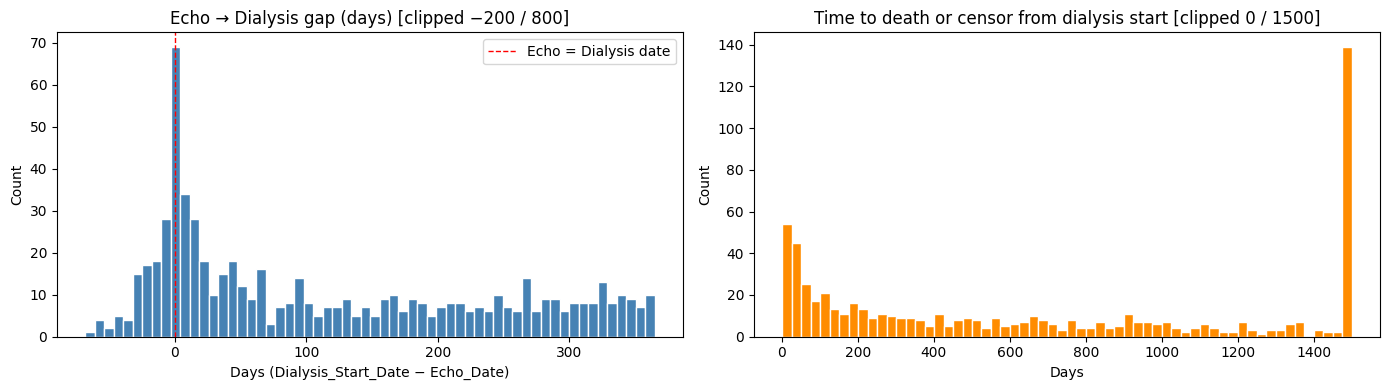

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    df["gap_echo_to_dial_days"].dropna().clip(-200, 800),
    bins=60, color="steelblue", edgecolor="white"
)
axes[0].set_title("Echo → Dialysis gap (days) [clipped −200 / 800]")
axes[0].set_xlabel("Days (Dialysis_Start_Date − Echo_Date)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="Echo = Dialysis date")
axes[0].legend()

axes[1].hist(
    df["time_to_event_or_censor_days"].dropna().clip(0, 1500),
    bins=60, color="darkorange", edgecolor="white"
)
axes[1].set_title("Time to death or censor from dialysis start [clipped 0 / 1500]")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## Notes & known limitations

| Issue | Details |
|---|---|
| **Censor date proxy** | If `COL_LAST_FU` is None, the script uses `max(all dates)` as a study-end proxy. This **underestimates** follow-up for patients whose last recorded event is early — replace with your administrative censor date. |
| **30.44 days/month** | Months are approximated as 30.44 days. For a 6-month window this introduces a ±1–2 day error; acceptable for EDA but use `pd.DateOffset(months=N)` in a strict inclusion criterion. |
| **Multiple echos** | If a patient has multiple echo rows, `gap_echo_to_dial_days` reflects each row individually. You may want to select only the *last echo before dialysis* per patient before applying the keep rule. |
| **Death = NaT ≠ alive** | `death_event=0` means no death date recorded — this could be truly alive, lost to follow-up, or a data gap. Verify with your registry. |
| **pandas ≥ 2.0 datetime quantile** | `pd.Series.quantile()` on datetimes is deprecated in pandas 2.x. The updated `rich_date_summary` uses `np.percentile` on int64 nanoseconds instead. |